# $\xi=0.05$

Collected 7224 I_r(t) and 7223 I_r(t+1) samples.
Collected 7819 I_d(t) and 7819 I_d(t+1) samples.
Collected 7819 I_g(t) and 7819 I_g(t+1) samples.
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.05/Ir_kde_all.png


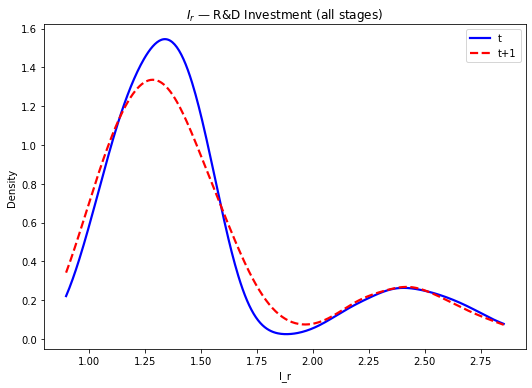

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.05/Ir_kde_all_by_lambda3.png


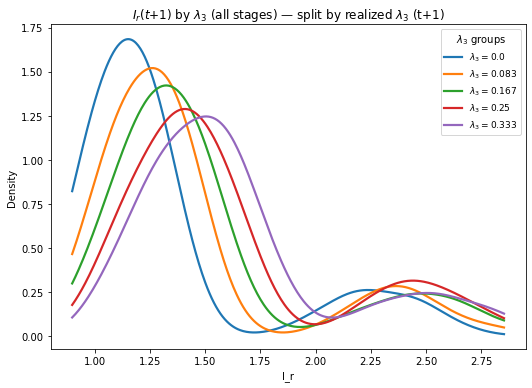

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.05/Id_kde_all.png


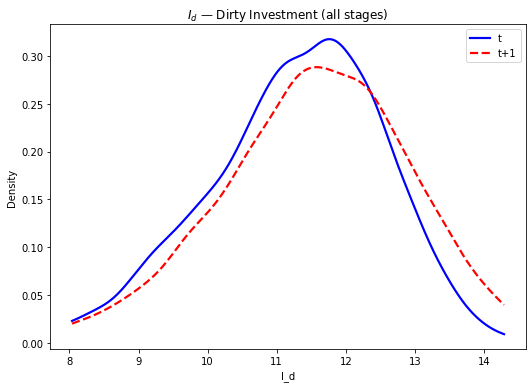

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.05/Id_kde_all_by_lambda3.png


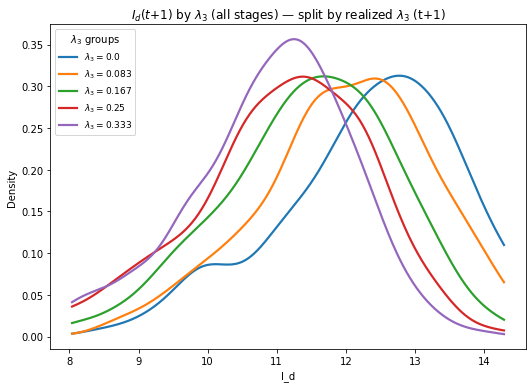

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.05/Ig_kde_all.png


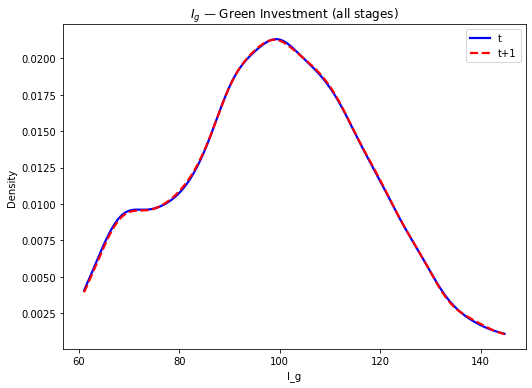

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.05/Ig_kde_all_by_lambda3.png


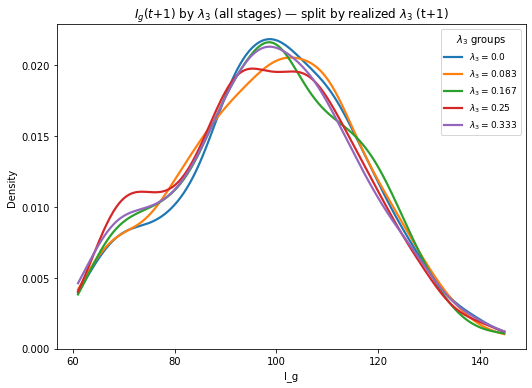

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.05/Ir_kde_stage0.png


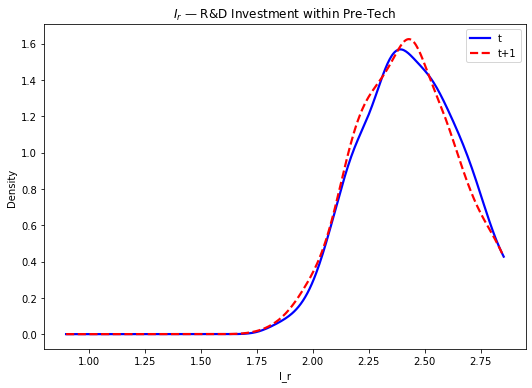

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.05/Ir_kde_stage0_by_lambda3.png


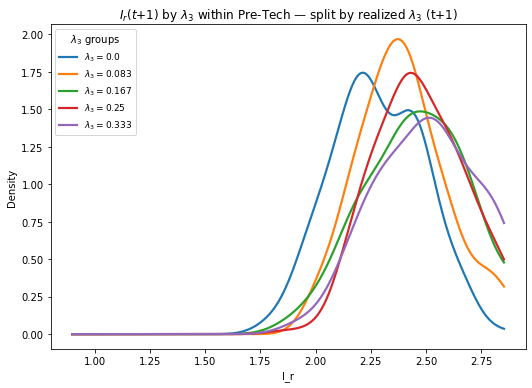

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.05/Id_kde_stage0.png


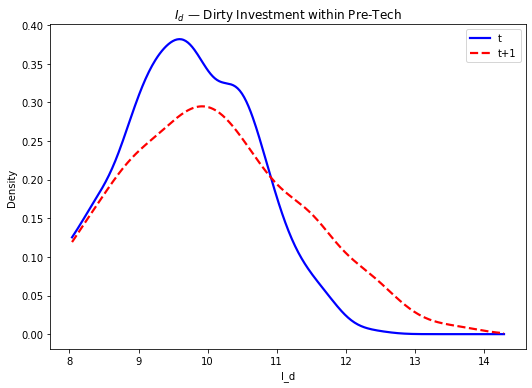

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.05/Id_kde_stage0_by_lambda3.png


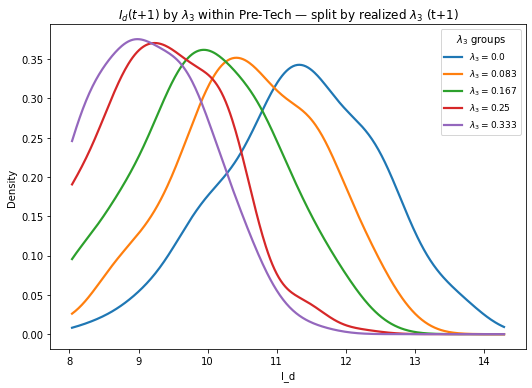

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.05/Ig_kde_stage0.png


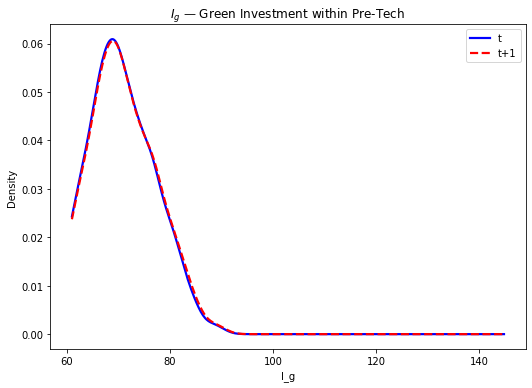

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.05/Ig_kde_stage0_by_lambda3.png


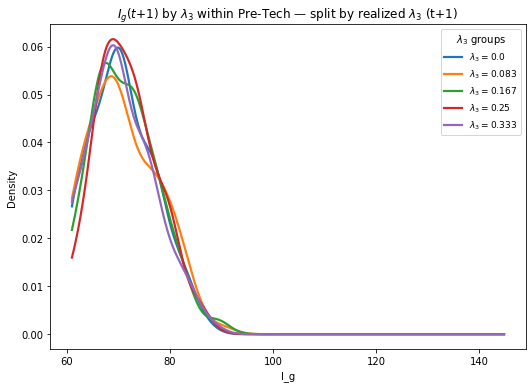

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.05/Ir_kde_stage1.png


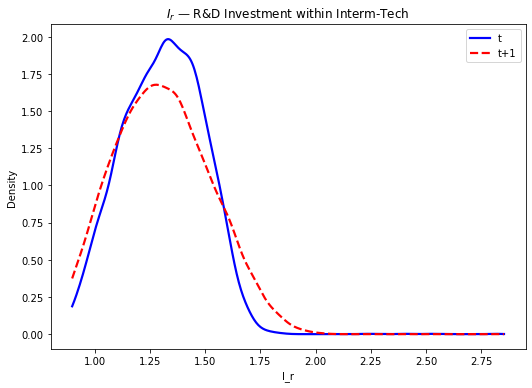

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.05/Ir_kde_stage1_by_lambda3.png


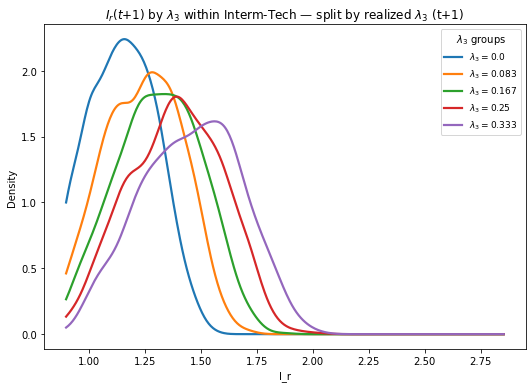

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.05/Id_kde_stage1.png


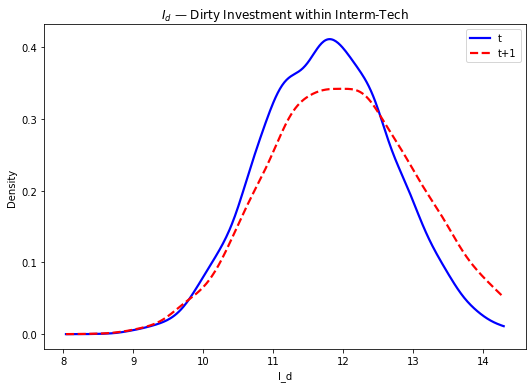

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.05/Id_kde_stage1_by_lambda3.png


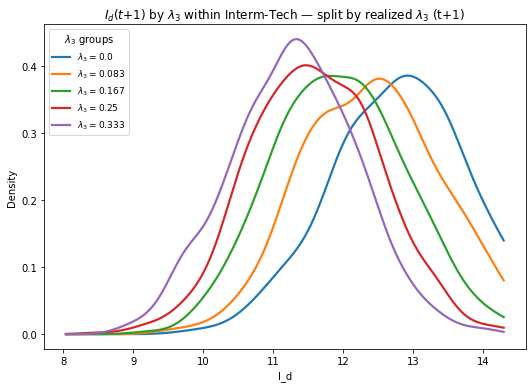

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.05/Ig_kde_stage1.png


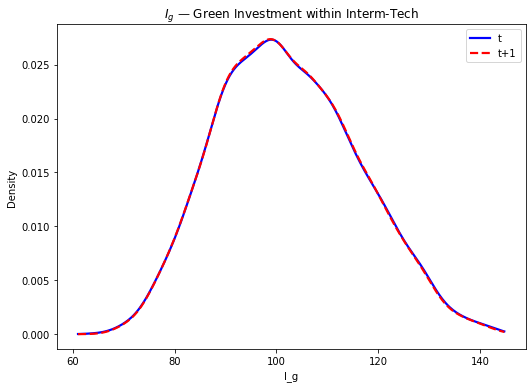

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.05/Ig_kde_stage1_by_lambda3.png


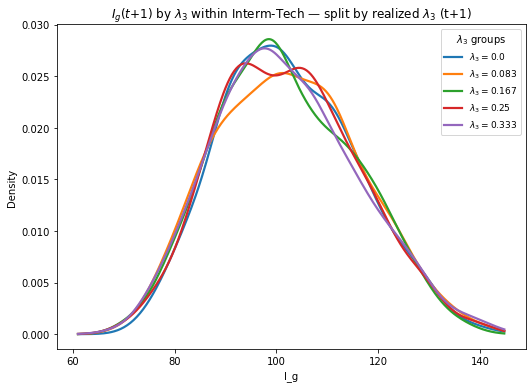

Skipping $I_r$ — R&D Investment within Post-Tech — insufficient data.
Skipping $I_r(t{+}1)$ by $\lambda_3$ within Post-Tech (by λ3) — no group meets MIN_PER_GROUP=10.
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.05/Id_kde_stage2.png


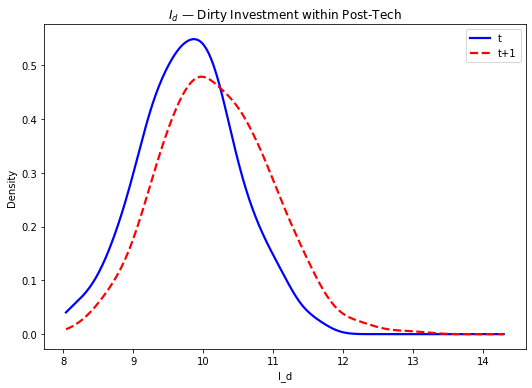

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.05/Id_kde_stage2_by_lambda3.png


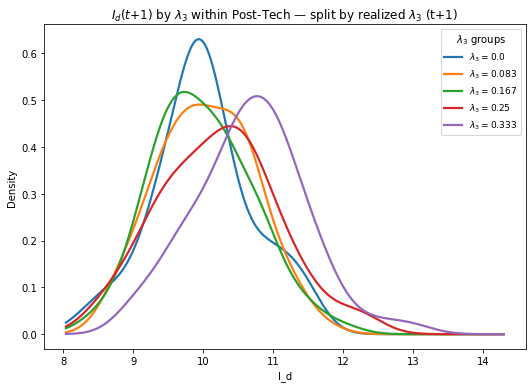

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.05/Ig_kde_stage2.png


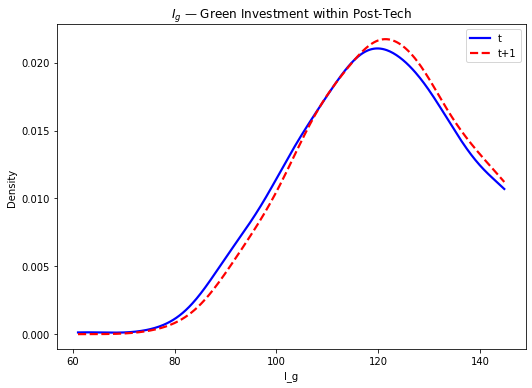

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.05/Ig_kde_stage2_by_lambda3.png


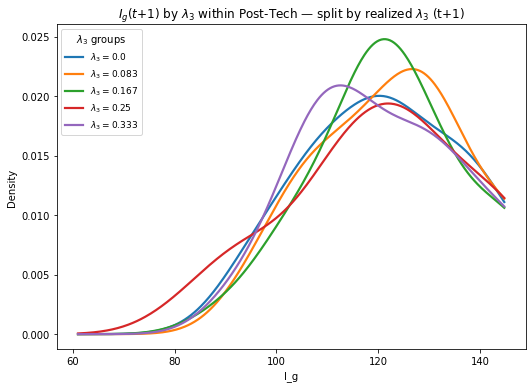

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from collections import defaultdict

# ---------- CONFIG ----------
base_folder = "/project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.05"
seed_min, seed_max = 1, 100
save_fig = True
STRICT_SAME_STAGE = True   # require tech stage(t) == stage(t+1) for stage-specific plots
LAMBDA3_ROUND = 3          # round λ3 values to group close floats
MIN_PER_GROUP = 10         # skip λ3 groups with too-few samples
# ----------------------------

Ir_t, Ir_t1 = [], []
Id_t, Id_t1 = [], []
Ig_t, Ig_t1 = [], []

# t+1 grouped by realized λ3 at the jump
Ir_t1_by_lam = defaultdict(list)
Id_t1_by_lam = defaultdict(list)
Ig_t1_by_lam = defaultdict(list)

stages = {0: "Pre-Tech", 1: "Interm-Tech", 2: "Post-Tech"}
Ir_stage = {s: {"t": [], "t1": []} for s in stages}
Id_stage = {s: {"t": [], "t1": []} for s in stages}
Ig_stage = {s: {"t": [], "t1": []} for s in stages}

# per-stage: t+1 grouped by λ3
Ir_t1_by_lam_stage = {s: defaultdict(list) for s in stages}
Id_t1_by_lam_stage = {s: defaultdict(list) for s in stages}
Ig_t1_by_lam_stage = {s: defaultdict(list) for s in stages}

def load_arrays(folder, seed):
    D   = np.load(os.path.join(folder, f"damage_state_array_{seed}.npy"))
    T   = np.load(os.path.join(folder, f"tech_state_array_{seed}.npy"))
    Ir  = np.load(os.path.join(folder, f"I_r_array_{seed}.npy"))
    Id  = np.load(os.path.join(folder, f"I_d_array_{seed}.npy"))
    Ig  = np.load(os.path.join(folder, f"I_g_array_{seed}.npy"))
    G3  = np.load(os.path.join(folder, f"gamma3_array_{seed}.npy"))  # realized λ3 path
    return D, T, Ir, Id, Ig, G3

for seed in range(seed_min, seed_max + 1):
    try:
        D, T, Ir, Id, Ig, G3 = load_arrays(base_folder, seed)
    except FileNotFoundError:
        print(f"[Seed {seed:03d}] missing files, skipping.")
        continue

    n_paths, T1 = D.shape
    for i in range(n_paths):
        d = D[i]
        # first transition 0 -> 1 (damage jump)
        trans = np.where((d[:-1] == 0) & (d[1:] == 1))[0]
        if trans.size == 0:
            continue
        t = trans[0] + 1  # index RIGHT AFTER the jump (compare t vs t+1)
        if t < 0 or t + 1 >= T1:
            continue

        ir_t,  ir_t1  = Ir[i, t],  Ir[i, t + 1]
        id_t,  id_t1  = Id[i, t],  Id[i, t + 1]
        ig_t,  ig_t1  = Ig[i, t],  Ig[i, t + 1]

        if np.isfinite(ir_t):  Ir_t.append(ir_t)
        if np.isfinite(ir_t1): Ir_t1.append(ir_t1)
        if np.isfinite(id_t):  Id_t.append(id_t)
        if np.isfinite(id_t1): Id_t1.append(id_t1)
        if np.isfinite(ig_t):  Ig_t.append(ig_t)
        if np.isfinite(ig_t1): Ig_t1.append(ig_t1)

        # realized λ3 at the jump time t (post-jump value)
        lam = G3[i, t]
        if np.isfinite(lam):
            lam_key = round(float(lam), LAMBDA3_ROUND) if LAMBDA3_ROUND is not None else float(lam)
            if np.isfinite(ir_t1): Ir_t1_by_lam[lam_key].append(ir_t1)
            if np.isfinite(id_t1): Id_t1_by_lam[lam_key].append(id_t1)
            if np.isfinite(ig_t1): Ig_t1_by_lam[lam_key].append(ig_t1)

        tb, ta = int(T[i, t]), int(T[i, t + 1])
        if tb in stages and ta in stages and ((not STRICT_SAME_STAGE) or (tb == ta)):
            s = tb
            if np.isfinite(ir_t):  Ir_stage[s]["t"].append(ir_t)
            if np.isfinite(ir_t1): Ir_stage[s]["t1"].append(ir_t1)
            if np.isfinite(id_t):  Id_stage[s]["t"].append(id_t)
            if np.isfinite(id_t1): Id_stage[s]["t1"].append(id_t1)
            if np.isfinite(ig_t):  Ig_stage[s]["t"].append(ig_t)
            if np.isfinite(ig_t1): Ig_stage[s]["t1"].append(ig_t1)

            # per-stage λ3 grouping for t+1
            if np.isfinite(lam) and np.isfinite(ir_t1):
                Ir_t1_by_lam_stage[s][lam_key].append(ir_t1)
            if np.isfinite(lam) and np.isfinite(id_t1):
                Id_t1_by_lam_stage[s][lam_key].append(id_t1)
            if np.isfinite(lam) and np.isfinite(ig_t1):
                Ig_t1_by_lam_stage[s][lam_key].append(ig_t1)

print(f"Collected {len(Ir_t)} I_r(t) and {len(Ir_t1)} I_r(t+1) samples.")
print(f"Collected {len(Id_t)} I_d(t) and {len(Id_t1)} I_d(t+1) samples.")
print(f"Collected {len(Ig_t)} I_g(t) and {len(Ig_t1)} I_g(t+1) samples.")

# ----------------------------
# Shared x-range (per variable)
# ----------------------------
def compute_range(arr):
    arr = np.asarray(arr, float)
    arr = arr[np.isfinite(arr)]
    if arr.size < 2:
        return None
    lo, hi = np.percentile(arr, [1, 99])
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        return None
    return (float(lo), float(hi))

Ir_all = np.array(Ir_t + Ir_t1, dtype=float)
Id_all = np.array(Id_t + Id_t1, dtype=float)
Ig_all = np.array(Ig_t + Ig_t1, dtype=float)

Ir_range = compute_range(Ir_all)
Id_range = compute_range(Id_all)
Ig_range = compute_range(Ig_all)

def plot_kde(data, label, color=None, linestyle="-", x_range=None):
    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]
    if data.size < 2:
        return False
    if np.allclose(np.std(data), 0):
        return False
    if x_range is None:
        lo, hi = np.percentile(data, [1, 99])
        if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
            return False
    else:
        lo, hi = x_range
    xs = np.linspace(lo, hi, 400)
    kde = gaussian_kde(data)
    if color is None:
        plt.plot(xs, kde(xs), lw=2.2, linestyle=linestyle, label=label)
    else:
        plt.plot(xs, kde(xs), color=color, lw=2.2, linestyle=linestyle, label=label)
    return True

def plot_density(x_t, x_t1, xlabel, title, filename, x_range=None):
    x_t  = [v for v in x_t  if np.isfinite(v)]
    x_t1 = [v for v in x_t1 if np.isfinite(v)]
    if len(x_t) == 0 or len(x_t1) == 0:
        print(f"Skipping {title} — insufficient data.")
        return

    plt.figure(figsize=(7.5, 5.5))
    ok1 = plot_kde(x_t,  "t",   "blue", "-", x_range=x_range)
    ok2 = plot_kde(x_t1, "t+1", "red",  "--", x_range=x_range)
    if not (ok1 and ok2):
        print(f"Skipping {title} — insufficient variance.")
        plt.close()
        return

    plt.xlabel(xlabel)
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    if save_fig:
        out = os.path.join(base_folder, filename)
        plt.savefig(out, dpi=150)
        print(f"Saved: {out}")
    plt.show()

def plot_density_by_lambda(groups_dict, xlabel, title, filename, x_range=None):
    """Plot t+1 density split by realized λ3 groups."""
    items = [(k, v) for k, v in groups_dict.items() if len(v) >= MIN_PER_GROUP]
    if len(items) == 0:
        print(f"Skipping {title} (by λ3) — no group meets MIN_PER_GROUP={MIN_PER_GROUP}.")
        return
    items.sort(key=lambda kv: kv[0])

    plt.figure(figsize=(7.5, 5.5))
    plotted = 0
    for lam, arr in items:
        ok = plot_kde(arr, label=fr"$\lambda_3={lam}$", x_range=x_range)
        if ok:
            plotted += 1
    if plotted < 1:
        print(f"Skipping {title} (by λ3) — insufficient variance.")
        plt.close()
        return

    plt.xlabel(xlabel)
    plt.ylabel("Density")
    plt.title(title + " — split by realized $\lambda_3$ (t+1)")
    plt.legend(title=r"$\lambda_3$ groups", fontsize=9)
    plt.tight_layout()
    if save_fig:
        out = os.path.join(base_folder, filename)
        plt.savefig(out, dpi=150)
        print(f"Saved: {out}")
    plt.show()

# ---- Pooled ----
plot_density(Ir_t, Ir_t1, "I_r", r"$I_r$ — R&D Investment (all stages)",
             "Ir_kde_all.png", x_range=Ir_range)
plot_density_by_lambda(Ir_t1_by_lam, "I_r",
             r"$I_r(t{+}1)$ by $\lambda_3$ (all stages)",
             "Ir_kde_all_by_lambda3.png", x_range=Ir_range)

plot_density(Id_t, Id_t1, "I_d", r"$I_d$ — Dirty Investment (all stages)",
             "Id_kde_all.png", x_range=Id_range)
plot_density_by_lambda(Id_t1_by_lam, "I_d",
             r"$I_d(t{+}1)$ by $\lambda_3$ (all stages)",
             "Id_kde_all_by_lambda3.png", x_range=Id_range)

plot_density(Ig_t, Ig_t1, "I_g", r"$I_g$ — Green Investment (all stages)",
             "Ig_kde_all.png", x_range=Ig_range)
plot_density_by_lambda(Ig_t1_by_lam, "I_g",
             r"$I_g(t{+}1)$ by $\lambda_3$ (all stages)",
             "Ig_kde_all_by_lambda3.png", x_range=Ig_range)

# ---- Per-tech-stage ----
for s, name in stages.items():
    plot_density(Ir_stage[s]["t"], Ir_stage[s]["t1"], "I_r",
                 rf"$I_r$ — R&D Investment within {name}", f"Ir_kde_stage{s}.png",
                 x_range=Ir_range)
    plot_density_by_lambda(Ir_t1_by_lam_stage[s], "I_r",
                           rf"$I_r(t{{+}}1)$ by $\lambda_3$ within {name}",
                           f"Ir_kde_stage{s}_by_lambda3.png", x_range=Ir_range)

    plot_density(Id_stage[s]["t"], Id_stage[s]["t1"], "I_d",
                 rf"$I_d$ — Dirty Investment within {name}", f"Id_kde_stage{s}.png",
                 x_range=Id_range)
    plot_density_by_lambda(Id_t1_by_lam_stage[s], "I_d",
                           rf"$I_d(t{{+}}1)$ by $\lambda_3$ within {name}",
                           f"Id_kde_stage{s}_by_lambda3.png", x_range=Id_range)

    plot_density(Ig_stage[s]["t"], Ig_stage[s]["t1"], "I_g",
                 rf"$I_g$ — Green Investment within {name}", f"Ig_kde_stage{s}.png",
                 x_range=Ig_range)
    plot_density_by_lambda(Ig_t1_by_lam_stage[s], "I_g",
                           rf"$I_g(t{{+}}1)$ by $\lambda_3$ within {name}",
                           f"Ig_kde_stage{s}_by_lambda3.png", x_range=Ig_range)


# $\xi=0.1$

Collected 7395 I_r(t) and 7391 I_r(t+1) samples.
Collected 7929 I_d(t) and 7929 I_d(t+1) samples.
Collected 7929 I_g(t) and 7929 I_g(t+1) samples.
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.1/Ir_kde_all.png


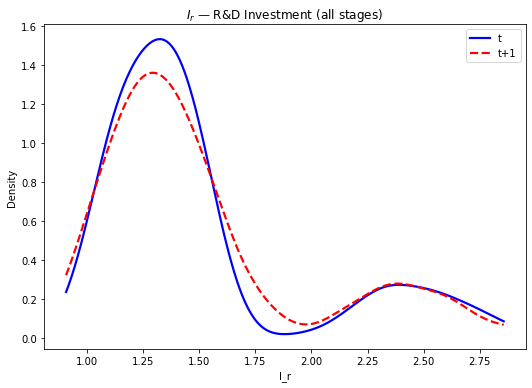

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.1/Ir_kde_all_by_lambda3.png


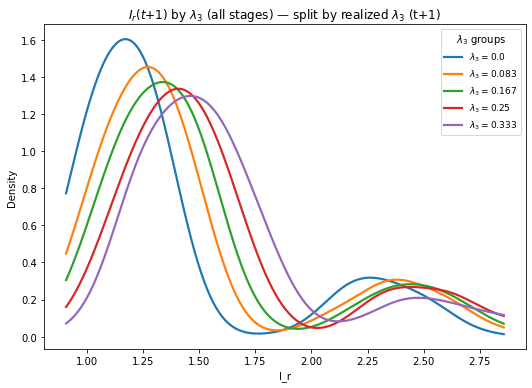

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.1/Id_kde_all.png


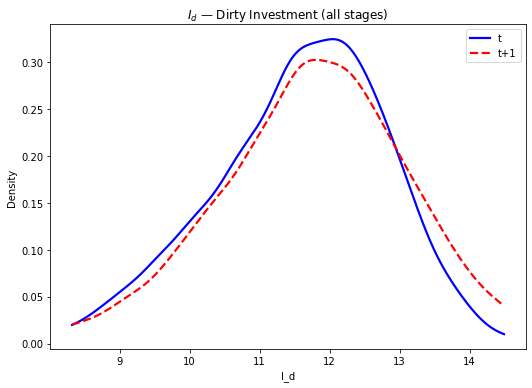

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.1/Id_kde_all_by_lambda3.png


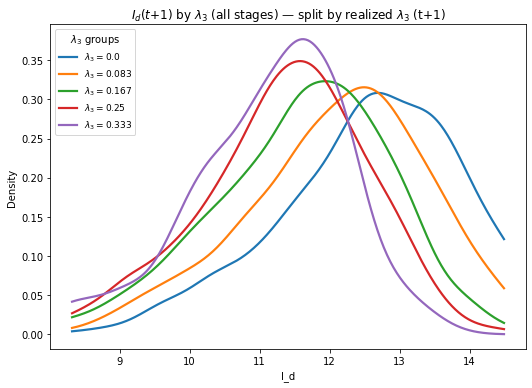

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.1/Ig_kde_all.png


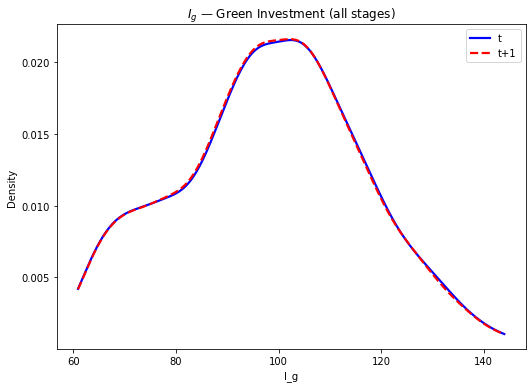

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.1/Ig_kde_all_by_lambda3.png


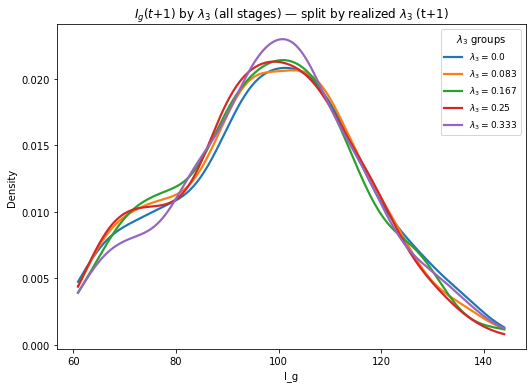

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.1/Ir_kde_stage0.png


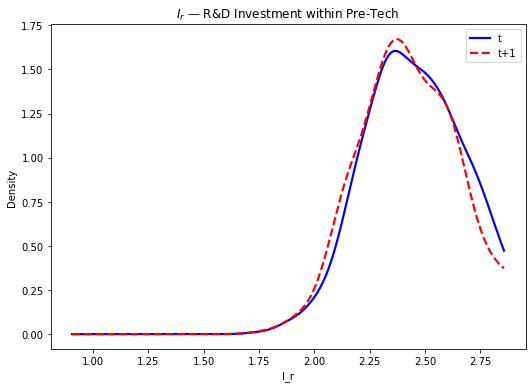

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.1/Ir_kde_stage0_by_lambda3.png


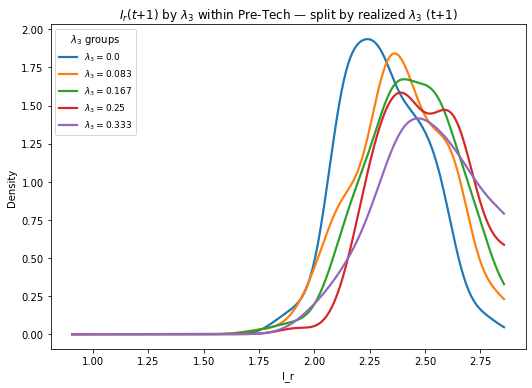

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.1/Id_kde_stage0.png


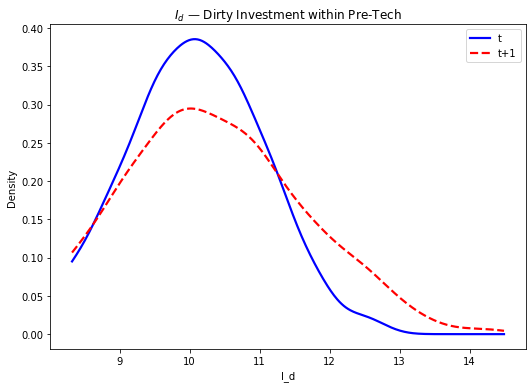

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.1/Id_kde_stage0_by_lambda3.png


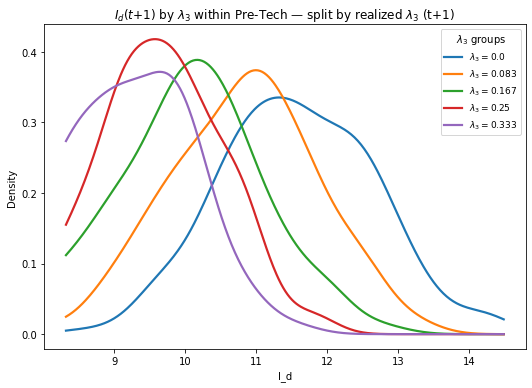

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.1/Ig_kde_stage0.png


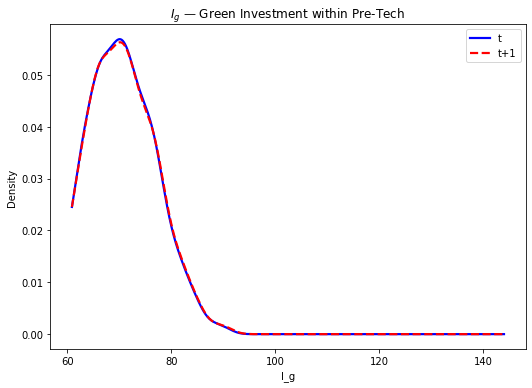

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.1/Ig_kde_stage0_by_lambda3.png


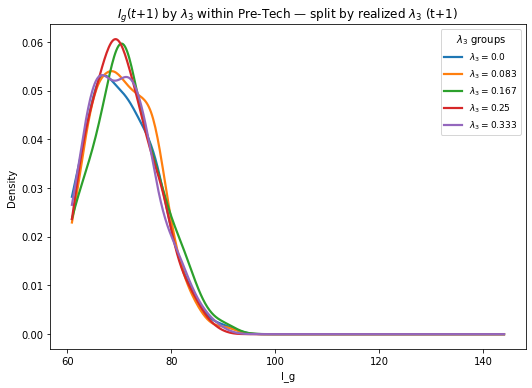

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.1/Ir_kde_stage1.png


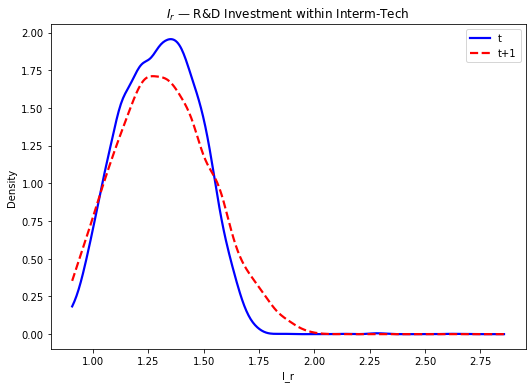

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.1/Ir_kde_stage1_by_lambda3.png


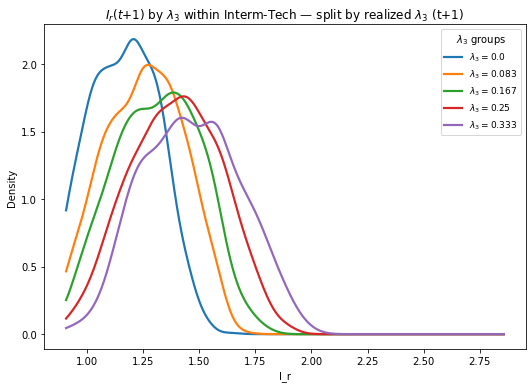

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.1/Id_kde_stage1.png


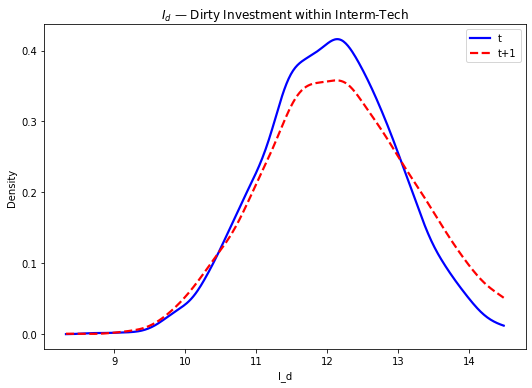

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.1/Id_kde_stage1_by_lambda3.png


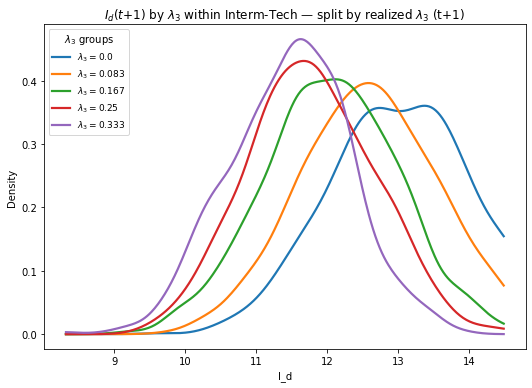

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.1/Ig_kde_stage1.png


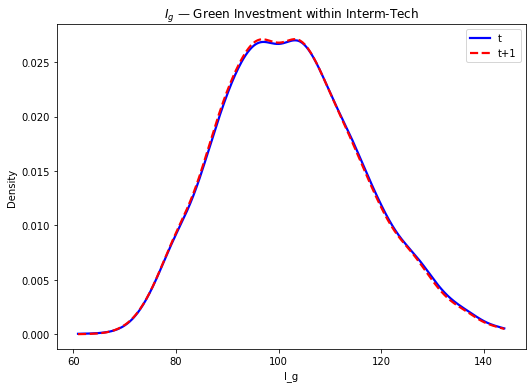

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.1/Ig_kde_stage1_by_lambda3.png


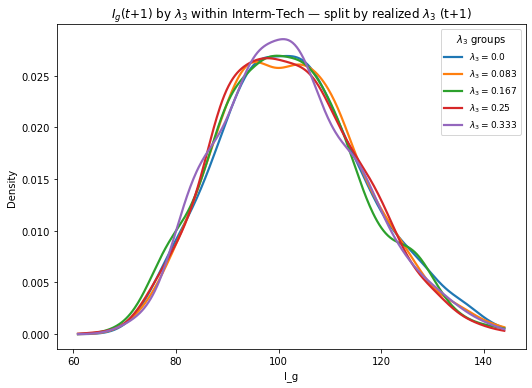

Skipping $I_r$ — R&D Investment within Post-Tech — insufficient data.
Skipping $I_r(t{+}1)$ by $\lambda_3$ within Post-Tech (by λ3) — no group meets MIN_PER_GROUP=10.
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.1/Id_kde_stage2.png


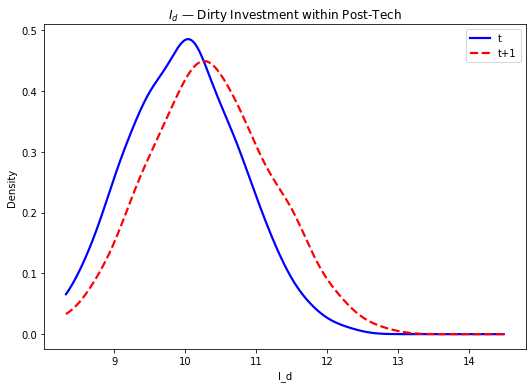

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.1/Id_kde_stage2_by_lambda3.png


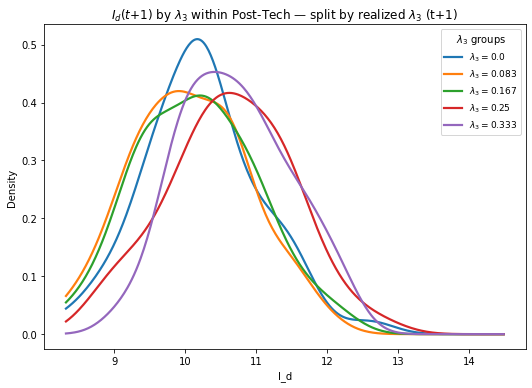

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.1/Ig_kde_stage2.png


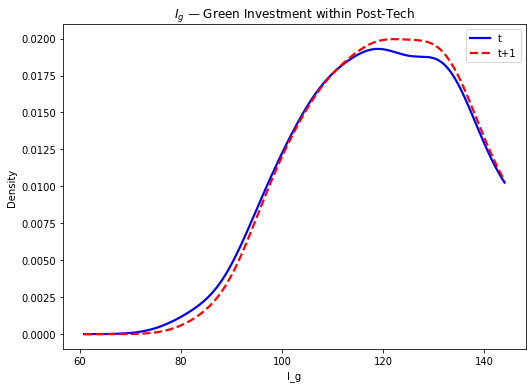

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.1/Ig_kde_stage2_by_lambda3.png


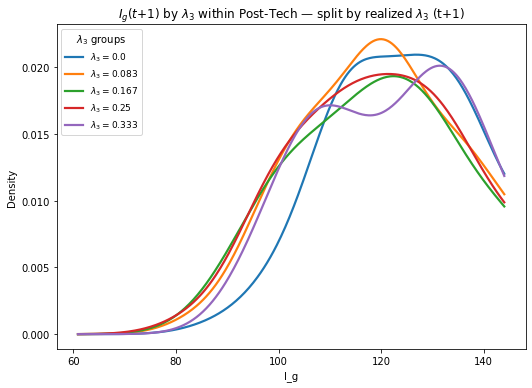

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# ---------- CONFIG ----------
base_folder = "/project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.1"
 
seed_min, seed_max = 1, 100
save_fig = True
STRICT_SAME_STAGE = True   # require tech stage(t) == stage(t+1) for stage-specific plots
LAMBDA3_ROUND = 3          # round λ3 values to group close floats
MIN_PER_GROUP = 10         # skip λ3 groups with too-few samples
# ----------------------------

Ir_t, Ir_t1 = [], []
Id_t, Id_t1 = [], []
Ig_t, Ig_t1 = [], []

# t+1 grouped by realized λ3 at the jump
Ir_t1_by_lam = defaultdict(list)
Id_t1_by_lam = defaultdict(list)
Ig_t1_by_lam = defaultdict(list)

stages = {0: "Pre-Tech", 1: "Interm-Tech", 2: "Post-Tech"}
Ir_stage = {s: {"t": [], "t1": []} for s in stages}
Id_stage = {s: {"t": [], "t1": []} for s in stages}
Ig_stage = {s: {"t": [], "t1": []} for s in stages}

# per-stage: t+1 grouped by λ3
Ir_t1_by_lam_stage = {s: defaultdict(list) for s in stages}
Id_t1_by_lam_stage = {s: defaultdict(list) for s in stages}
Ig_t1_by_lam_stage = {s: defaultdict(list) for s in stages}

def load_arrays(folder, seed):
    D   = np.load(os.path.join(folder, f"damage_state_array_{seed}.npy"))
    T   = np.load(os.path.join(folder, f"tech_state_array_{seed}.npy"))
    Ir  = np.load(os.path.join(folder, f"I_r_array_{seed}.npy"))
    Id  = np.load(os.path.join(folder, f"I_d_array_{seed}.npy"))
    Ig  = np.load(os.path.join(folder, f"I_g_array_{seed}.npy"))
    G3  = np.load(os.path.join(folder, f"gamma3_array_{seed}.npy"))  # realized λ3 path
    return D, T, Ir, Id, Ig, G3

for seed in range(seed_min, seed_max + 1):
    try:
        D, T, Ir, Id, Ig, G3 = load_arrays(base_folder, seed)
    except FileNotFoundError:
        print(f"[Seed {seed:03d}] missing files, skipping.")
        continue

    n_paths, T1 = D.shape
    for i in range(n_paths):
        d = D[i]
        # first transition 0 -> 1 (damage jump)
        trans = np.where((d[:-1] == 0) & (d[1:] == 1))[0]
        if trans.size == 0:
            continue
        t = trans[0] + 1  # index RIGHT AFTER the jump (compare t vs t+1)
        if t < 0 or t + 1 >= T1:
            continue

        ir_t,  ir_t1  = Ir[i, t],  Ir[i, t + 1]
        id_t,  id_t1  = Id[i, t],  Id[i, t + 1]
        ig_t,  ig_t1  = Ig[i, t],  Ig[i, t + 1]

        if np.isfinite(ir_t):  Ir_t.append(ir_t)
        if np.isfinite(ir_t1): Ir_t1.append(ir_t1)
        if np.isfinite(id_t):  Id_t.append(id_t)
        if np.isfinite(id_t1): Id_t1.append(id_t1)
        if np.isfinite(ig_t):  Ig_t.append(ig_t)
        if np.isfinite(ig_t1): Ig_t1.append(ig_t1)

        # realized λ3 at the jump time t (post-jump value)
        lam = G3[i, t]
        if np.isfinite(lam):
            lam_key = round(float(lam), LAMBDA3_ROUND) if LAMBDA3_ROUND is not None else float(lam)
            if np.isfinite(ir_t1): Ir_t1_by_lam[lam_key].append(ir_t1)
            if np.isfinite(id_t1): Id_t1_by_lam[lam_key].append(id_t1)
            if np.isfinite(ig_t1): Ig_t1_by_lam[lam_key].append(ig_t1)

        tb, ta = int(T[i, t]), int(T[i, t + 1])
        if tb in stages and ta in stages and ((not STRICT_SAME_STAGE) or (tb == ta)):
            s = tb
            if np.isfinite(ir_t):  Ir_stage[s]["t"].append(ir_t)
            if np.isfinite(ir_t1): Ir_stage[s]["t1"].append(ir_t1)
            if np.isfinite(id_t):  Id_stage[s]["t"].append(id_t)
            if np.isfinite(id_t1): Id_stage[s]["t1"].append(id_t1)
            if np.isfinite(ig_t):  Ig_stage[s]["t"].append(ig_t)
            if np.isfinite(ig_t1): Ig_stage[s]["t1"].append(ig_t1)

            # per-stage λ3 grouping for t+1
            if np.isfinite(lam) and np.isfinite(ir_t1):
                Ir_t1_by_lam_stage[s][lam_key].append(ir_t1)
            if np.isfinite(lam) and np.isfinite(id_t1):
                Id_t1_by_lam_stage[s][lam_key].append(id_t1)
            if np.isfinite(lam) and np.isfinite(ig_t1):
                Ig_t1_by_lam_stage[s][lam_key].append(ig_t1)

print(f"Collected {len(Ir_t)} I_r(t) and {len(Ir_t1)} I_r(t+1) samples.")
print(f"Collected {len(Id_t)} I_d(t) and {len(Id_t1)} I_d(t+1) samples.")
print(f"Collected {len(Ig_t)} I_g(t) and {len(Ig_t1)} I_g(t+1) samples.")

# ----------------------------
# Shared x-range (per variable)
# ----------------------------
def compute_range(arr):
    arr = np.asarray(arr, float)
    arr = arr[np.isfinite(arr)]
    if arr.size < 2:
        return None
    lo, hi = np.percentile(arr, [1, 99])
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        return None
    return (float(lo), float(hi))

Ir_all = np.array(Ir_t + Ir_t1, dtype=float)
Id_all = np.array(Id_t + Id_t1, dtype=float)
Ig_all = np.array(Ig_t + Ig_t1, dtype=float)

Ir_range = compute_range(Ir_all)
Id_range = compute_range(Id_all)
Ig_range = compute_range(Ig_all)

def plot_kde(data, label, color=None, linestyle="-", x_range=None):
    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]
    if data.size < 2:
        return False
    if np.allclose(np.std(data), 0):
        return False
    if x_range is None:
        lo, hi = np.percentile(data, [1, 99])
        if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
            return False
    else:
        lo, hi = x_range
    xs = np.linspace(lo, hi, 400)
    kde = gaussian_kde(data)
    if color is None:
        plt.plot(xs, kde(xs), lw=2.2, linestyle=linestyle, label=label)
    else:
        plt.plot(xs, kde(xs), color=color, lw=2.2, linestyle=linestyle, label=label)
    return True

def plot_density(x_t, x_t1, xlabel, title, filename, x_range=None):
    x_t  = [v for v in x_t  if np.isfinite(v)]
    x_t1 = [v for v in x_t1 if np.isfinite(v)]
    if len(x_t) == 0 or len(x_t1) == 0:
        print(f"Skipping {title} — insufficient data.")
        return

    plt.figure(figsize=(7.5, 5.5))
    ok1 = plot_kde(x_t,  "t",   "blue", "-", x_range=x_range)
    ok2 = plot_kde(x_t1, "t+1", "red",  "--", x_range=x_range)
    if not (ok1 and ok2):
        print(f"Skipping {title} — insufficient variance.")
        plt.close()
        return

    plt.xlabel(xlabel)
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    if save_fig:
        out = os.path.join(base_folder, filename)
        plt.savefig(out, dpi=150)
        print(f"Saved: {out}")
    plt.show()

def plot_density_by_lambda(groups_dict, xlabel, title, filename, x_range=None):
    """Plot t+1 density split by realized λ3 groups."""
    items = [(k, v) for k, v in groups_dict.items() if len(v) >= MIN_PER_GROUP]
    if len(items) == 0:
        print(f"Skipping {title} (by λ3) — no group meets MIN_PER_GROUP={MIN_PER_GROUP}.")
        return
    items.sort(key=lambda kv: kv[0])

    plt.figure(figsize=(7.5, 5.5))
    plotted = 0
    for lam, arr in items:
        ok = plot_kde(arr, label=fr"$\lambda_3={lam}$", x_range=x_range)
        if ok:
            plotted += 1
    if plotted < 1:
        print(f"Skipping {title} (by λ3) — insufficient variance.")
        plt.close()
        return

    plt.xlabel(xlabel)
    plt.ylabel("Density")
    plt.title(title + " — split by realized $\lambda_3$ (t+1)")
    plt.legend(title=r"$\lambda_3$ groups", fontsize=9)
    plt.tight_layout()
    if save_fig:
        out = os.path.join(base_folder, filename)
        plt.savefig(out, dpi=150)
        print(f"Saved: {out}")
    plt.show()

# ---- Pooled ----
plot_density(Ir_t, Ir_t1, "I_r", r"$I_r$ — R&D Investment (all stages)",
             "Ir_kde_all.png", x_range=Ir_range)
plot_density_by_lambda(Ir_t1_by_lam, "I_r",
             r"$I_r(t{+}1)$ by $\lambda_3$ (all stages)",
             "Ir_kde_all_by_lambda3.png", x_range=Ir_range)

plot_density(Id_t, Id_t1, "I_d", r"$I_d$ — Dirty Investment (all stages)",
             "Id_kde_all.png", x_range=Id_range)
plot_density_by_lambda(Id_t1_by_lam, "I_d",
             r"$I_d(t{+}1)$ by $\lambda_3$ (all stages)",
             "Id_kde_all_by_lambda3.png", x_range=Id_range)

plot_density(Ig_t, Ig_t1, "I_g", r"$I_g$ — Green Investment (all stages)",
             "Ig_kde_all.png", x_range=Ig_range)
plot_density_by_lambda(Ig_t1_by_lam, "I_g",
             r"$I_g(t{+}1)$ by $\lambda_3$ (all stages)",
             "Ig_kde_all_by_lambda3.png", x_range=Ig_range)

# ---- Per-tech-stage ----
for s, name in stages.items():
    plot_density(Ir_stage[s]["t"], Ir_stage[s]["t1"], "I_r",
                 rf"$I_r$ — R&D Investment within {name}", f"Ir_kde_stage{s}.png",
                 x_range=Ir_range)
    plot_density_by_lambda(Ir_t1_by_lam_stage[s], "I_r",
                           rf"$I_r(t{{+}}1)$ by $\lambda_3$ within {name}",
                           f"Ir_kde_stage{s}_by_lambda3.png", x_range=Ir_range)

    plot_density(Id_stage[s]["t"], Id_stage[s]["t1"], "I_d",
                 rf"$I_d$ — Dirty Investment within {name}", f"Id_kde_stage{s}.png",
                 x_range=Id_range)
    plot_density_by_lambda(Id_t1_by_lam_stage[s], "I_d",
                           rf"$I_d(t{{+}}1)$ by $\lambda_3$ within {name}",
                           f"Id_kde_stage{s}_by_lambda3.png", x_range=Id_range)

    plot_density(Ig_stage[s]["t"], Ig_stage[s]["t1"], "I_g",
                 rf"$I_g$ — Green Investment within {name}", f"Ig_kde_stage{s}.png",
                 x_range=Ig_range)
    plot_density_by_lambda(Ig_t1_by_lam_stage[s], "I_g",
                           rf"$I_g(t{{+}}1)$ by $\lambda_3$ within {name}",
                           f"Ig_kde_stage{s}_by_lambda3.png", x_range=Ig_range)


# $\xi = 0.3$



Collected 7520 I_r(t) and 7520 I_r(t+1) samples.
Collected 8075 I_d(t) and 8075 I_d(t+1) samples.
Collected 8075 I_g(t) and 8075 I_g(t+1) samples.
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.3/Ir_kde_all.png


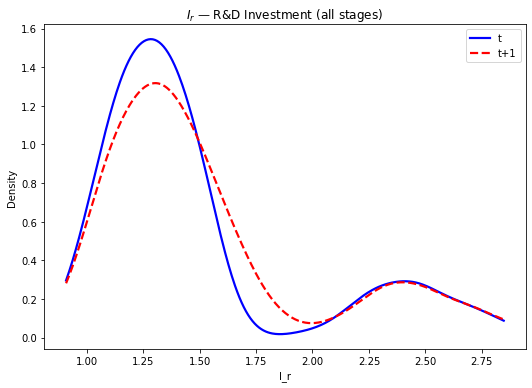

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.3/Ir_kde_all_by_lambda3.png


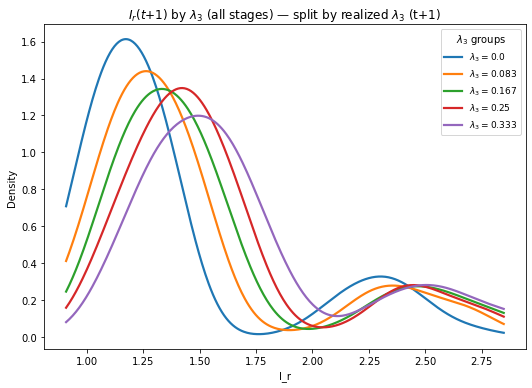

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.3/Id_kde_all.png


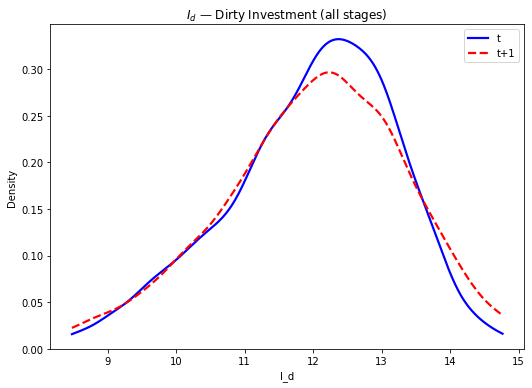

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.3/Id_kde_all_by_lambda3.png


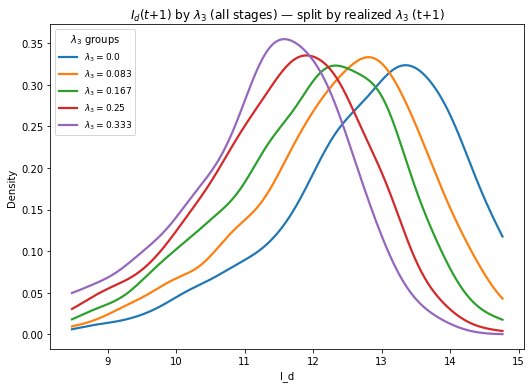

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.3/Ig_kde_all.png


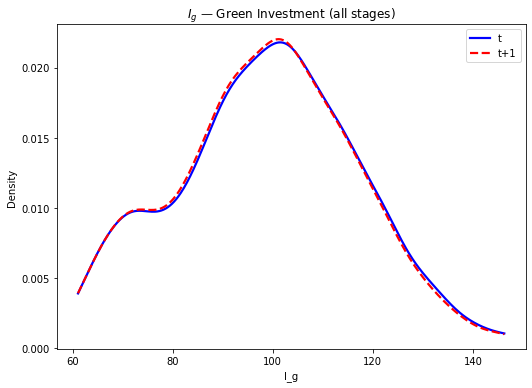

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.3/Ig_kde_all_by_lambda3.png


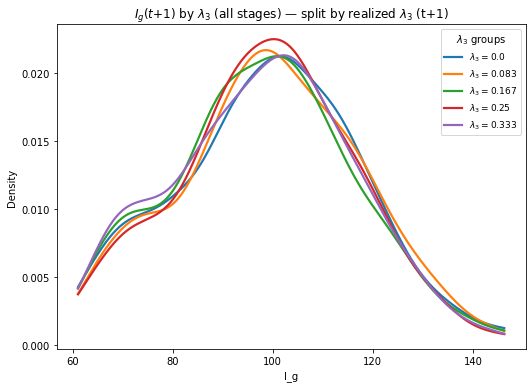

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.3/Ir_kde_stage0.png


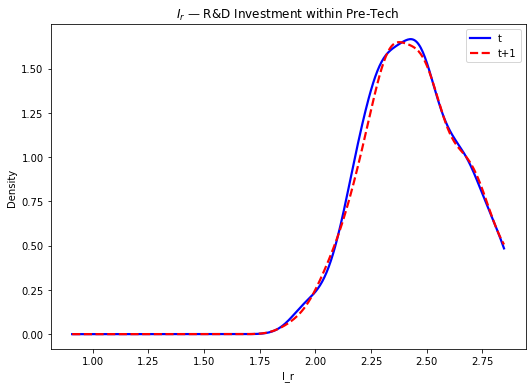

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.3/Ir_kde_stage0_by_lambda3.png


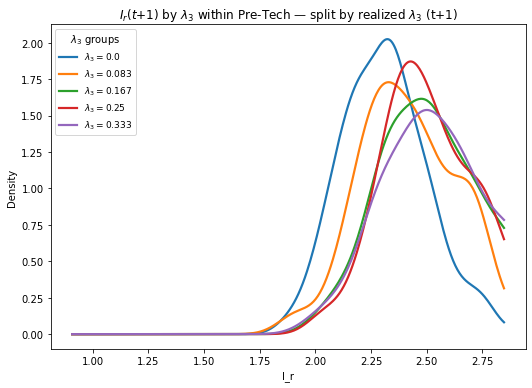

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.3/Id_kde_stage0.png


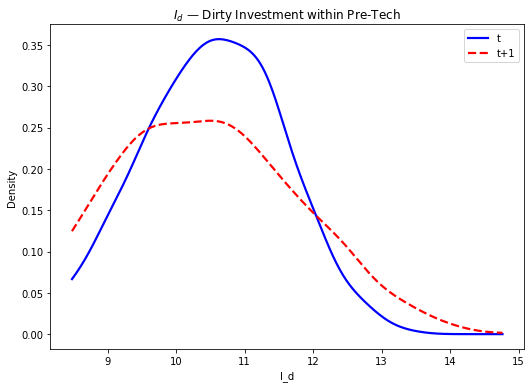

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.3/Id_kde_stage0_by_lambda3.png


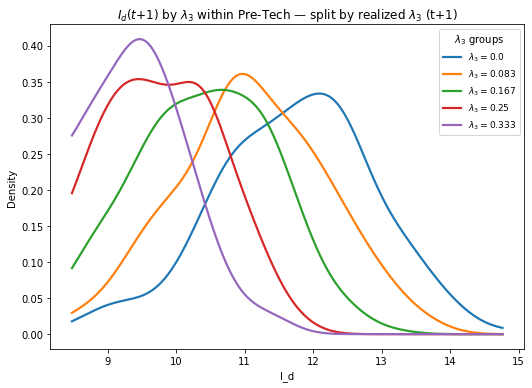

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.3/Ig_kde_stage0.png


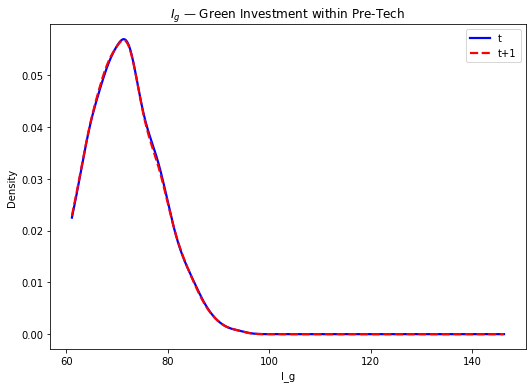

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.3/Ig_kde_stage0_by_lambda3.png


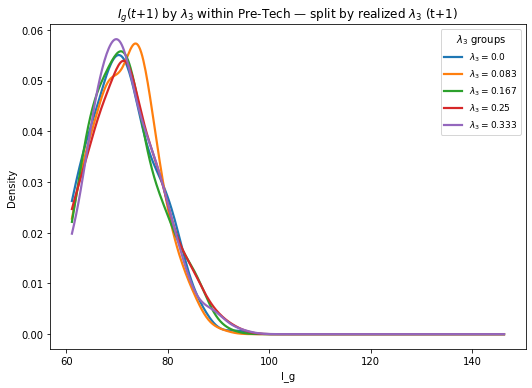

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.3/Ir_kde_stage1.png


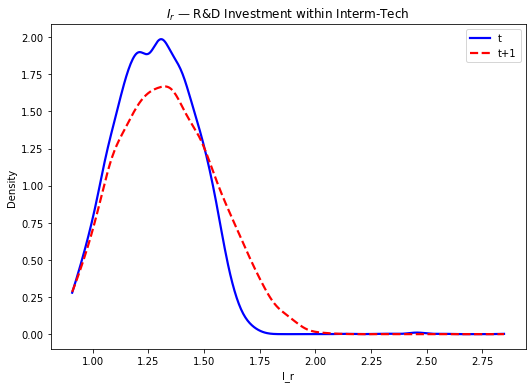

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.3/Ir_kde_stage1_by_lambda3.png


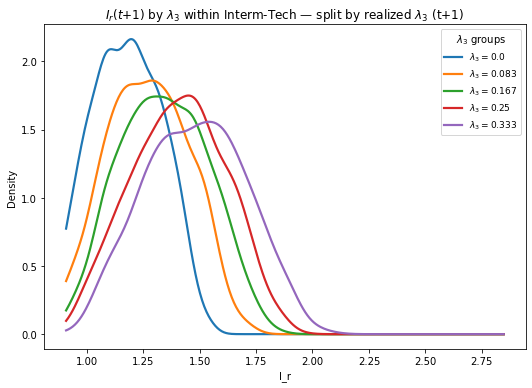

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.3/Id_kde_stage1.png


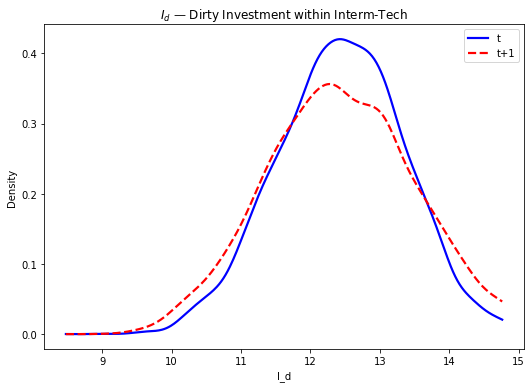

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.3/Id_kde_stage1_by_lambda3.png


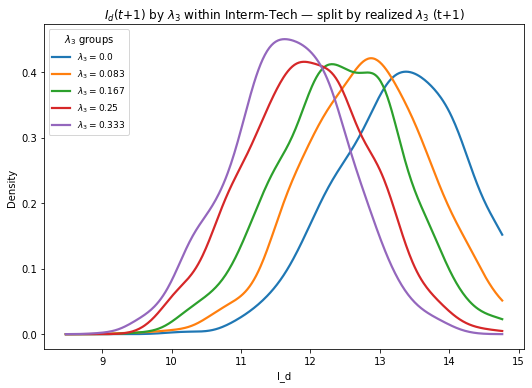

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.3/Ig_kde_stage1.png


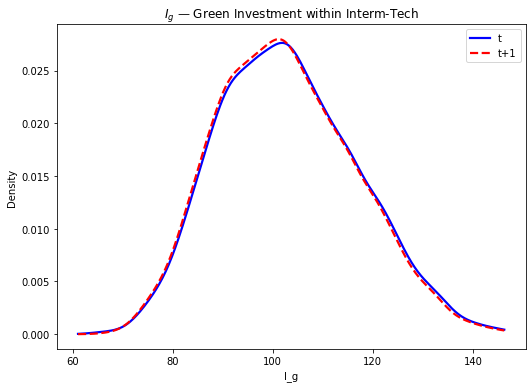

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.3/Ig_kde_stage1_by_lambda3.png


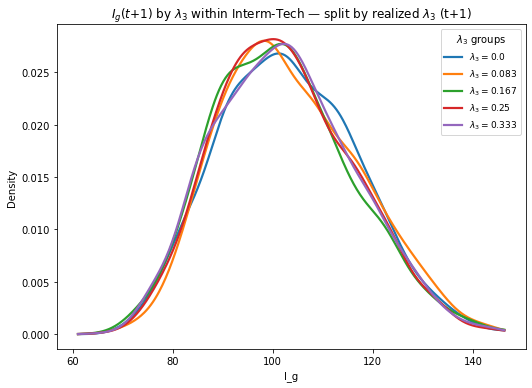

Skipping $I_r$ — R&D Investment within Post-Tech — insufficient data.
Skipping $I_r(t{+}1)$ by $\lambda_3$ within Post-Tech (by λ3) — no group meets MIN_PER_GROUP=10.
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.3/Id_kde_stage2.png


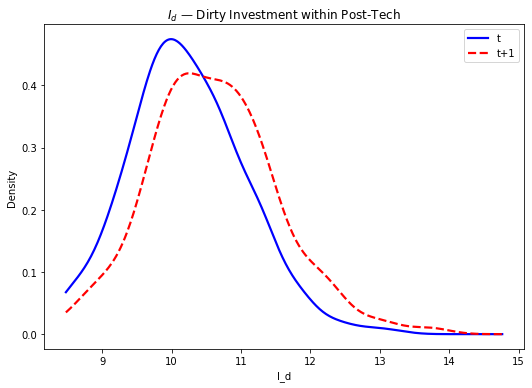

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.3/Id_kde_stage2_by_lambda3.png


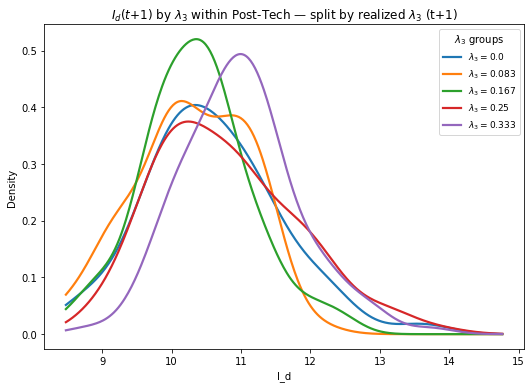

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.3/Ig_kde_stage2.png


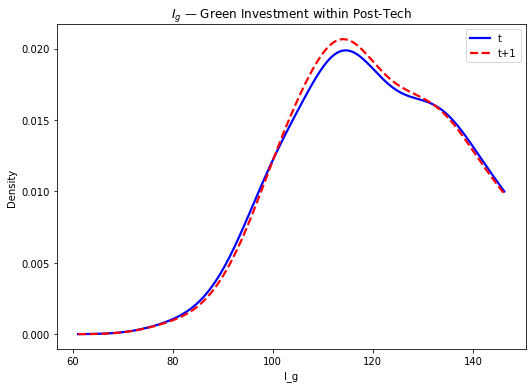

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.3/Ig_kde_stage2_by_lambda3.png


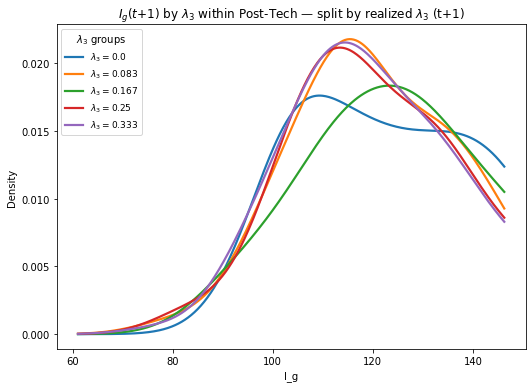

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# ---------- CONFIG ----------
base_folder = "/project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.3"
 
seed_min, seed_max = 1, 100
save_fig = True
STRICT_SAME_STAGE = True   # require tech stage(t) == stage(t+1) for stage-specific plots
LAMBDA3_ROUND = 3          # round λ3 values to group close floats
MIN_PER_GROUP = 10         # skip λ3 groups with too-few samples
# ----------------------------

Ir_t, Ir_t1 = [], []
Id_t, Id_t1 = [], []
Ig_t, Ig_t1 = [], []

# t+1 grouped by realized λ3 at the jump
Ir_t1_by_lam = defaultdict(list)
Id_t1_by_lam = defaultdict(list)
Ig_t1_by_lam = defaultdict(list)

stages = {0: "Pre-Tech", 1: "Interm-Tech", 2: "Post-Tech"}
Ir_stage = {s: {"t": [], "t1": []} for s in stages}
Id_stage = {s: {"t": [], "t1": []} for s in stages}
Ig_stage = {s: {"t": [], "t1": []} for s in stages}

# per-stage: t+1 grouped by λ3
Ir_t1_by_lam_stage = {s: defaultdict(list) for s in stages}
Id_t1_by_lam_stage = {s: defaultdict(list) for s in stages}
Ig_t1_by_lam_stage = {s: defaultdict(list) for s in stages}

def load_arrays(folder, seed):
    D   = np.load(os.path.join(folder, f"damage_state_array_{seed}.npy"))
    T   = np.load(os.path.join(folder, f"tech_state_array_{seed}.npy"))
    Ir  = np.load(os.path.join(folder, f"I_r_array_{seed}.npy"))
    Id  = np.load(os.path.join(folder, f"I_d_array_{seed}.npy"))
    Ig  = np.load(os.path.join(folder, f"I_g_array_{seed}.npy"))
    G3  = np.load(os.path.join(folder, f"gamma3_array_{seed}.npy"))  # realized λ3 path
    return D, T, Ir, Id, Ig, G3

for seed in range(seed_min, seed_max + 1):
    try:
        D, T, Ir, Id, Ig, G3 = load_arrays(base_folder, seed)
    except FileNotFoundError:
        print(f"[Seed {seed:03d}] missing files, skipping.")
        continue

    n_paths, T1 = D.shape
    for i in range(n_paths):
        d = D[i]
        # first transition 0 -> 1 (damage jump)
        trans = np.where((d[:-1] == 0) & (d[1:] == 1))[0]
        if trans.size == 0:
            continue
        t = trans[0] + 1  # index RIGHT AFTER the jump (compare t vs t+1)
        if t < 0 or t + 1 >= T1:
            continue

        ir_t,  ir_t1  = Ir[i, t],  Ir[i, t + 1]
        id_t,  id_t1  = Id[i, t],  Id[i, t + 1]
        ig_t,  ig_t1  = Ig[i, t],  Ig[i, t + 1]

        if np.isfinite(ir_t):  Ir_t.append(ir_t)
        if np.isfinite(ir_t1): Ir_t1.append(ir_t1)
        if np.isfinite(id_t):  Id_t.append(id_t)
        if np.isfinite(id_t1): Id_t1.append(id_t1)
        if np.isfinite(ig_t):  Ig_t.append(ig_t)
        if np.isfinite(ig_t1): Ig_t1.append(ig_t1)

        # realized λ3 at the jump time t (post-jump value)
        lam = G3[i, t]
        if np.isfinite(lam):
            lam_key = round(float(lam), LAMBDA3_ROUND) if LAMBDA3_ROUND is not None else float(lam)
            if np.isfinite(ir_t1): Ir_t1_by_lam[lam_key].append(ir_t1)
            if np.isfinite(id_t1): Id_t1_by_lam[lam_key].append(id_t1)
            if np.isfinite(ig_t1): Ig_t1_by_lam[lam_key].append(ig_t1)

        tb, ta = int(T[i, t]), int(T[i, t + 1])
        if tb in stages and ta in stages and ((not STRICT_SAME_STAGE) or (tb == ta)):
            s = tb
            if np.isfinite(ir_t):  Ir_stage[s]["t"].append(ir_t)
            if np.isfinite(ir_t1): Ir_stage[s]["t1"].append(ir_t1)
            if np.isfinite(id_t):  Id_stage[s]["t"].append(id_t)
            if np.isfinite(id_t1): Id_stage[s]["t1"].append(id_t1)
            if np.isfinite(ig_t):  Ig_stage[s]["t"].append(ig_t)
            if np.isfinite(ig_t1): Ig_stage[s]["t1"].append(ig_t1)

            # per-stage λ3 grouping for t+1
            if np.isfinite(lam) and np.isfinite(ir_t1):
                Ir_t1_by_lam_stage[s][lam_key].append(ir_t1)
            if np.isfinite(lam) and np.isfinite(id_t1):
                Id_t1_by_lam_stage[s][lam_key].append(id_t1)
            if np.isfinite(lam) and np.isfinite(ig_t1):
                Ig_t1_by_lam_stage[s][lam_key].append(ig_t1)

print(f"Collected {len(Ir_t)} I_r(t) and {len(Ir_t1)} I_r(t+1) samples.")
print(f"Collected {len(Id_t)} I_d(t) and {len(Id_t1)} I_d(t+1) samples.")
print(f"Collected {len(Ig_t)} I_g(t) and {len(Ig_t1)} I_g(t+1) samples.")

# ----------------------------
# Shared x-range (per variable)
# ----------------------------
def compute_range(arr):
    arr = np.asarray(arr, float)
    arr = arr[np.isfinite(arr)]
    if arr.size < 2:
        return None
    lo, hi = np.percentile(arr, [1, 99])
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        return None
    return (float(lo), float(hi))

Ir_all = np.array(Ir_t + Ir_t1, dtype=float)
Id_all = np.array(Id_t + Id_t1, dtype=float)
Ig_all = np.array(Ig_t + Ig_t1, dtype=float)

Ir_range = compute_range(Ir_all)
Id_range = compute_range(Id_all)
Ig_range = compute_range(Ig_all)

def plot_kde(data, label, color=None, linestyle="-", x_range=None):
    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]
    if data.size < 2:
        return False
    if np.allclose(np.std(data), 0):
        return False
    if x_range is None:
        lo, hi = np.percentile(data, [1, 99])
        if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
            return False
    else:
        lo, hi = x_range
    xs = np.linspace(lo, hi, 400)
    kde = gaussian_kde(data)
    if color is None:
        plt.plot(xs, kde(xs), lw=2.2, linestyle=linestyle, label=label)
    else:
        plt.plot(xs, kde(xs), color=color, lw=2.2, linestyle=linestyle, label=label)
    return True

def plot_density(x_t, x_t1, xlabel, title, filename, x_range=None):
    x_t  = [v for v in x_t  if np.isfinite(v)]
    x_t1 = [v for v in x_t1 if np.isfinite(v)]
    if len(x_t) == 0 or len(x_t1) == 0:
        print(f"Skipping {title} — insufficient data.")
        return

    plt.figure(figsize=(7.5, 5.5))
    ok1 = plot_kde(x_t,  "t",   "blue", "-", x_range=x_range)
    ok2 = plot_kde(x_t1, "t+1", "red",  "--", x_range=x_range)
    if not (ok1 and ok2):
        print(f"Skipping {title} — insufficient variance.")
        plt.close()
        return

    plt.xlabel(xlabel)
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    if save_fig:
        out = os.path.join(base_folder, filename)
        plt.savefig(out, dpi=150)
        print(f"Saved: {out}")
    plt.show()

def plot_density_by_lambda(groups_dict, xlabel, title, filename, x_range=None):
    """Plot t+1 density split by realized λ3 groups."""
    items = [(k, v) for k, v in groups_dict.items() if len(v) >= MIN_PER_GROUP]
    if len(items) == 0:
        print(f"Skipping {title} (by λ3) — no group meets MIN_PER_GROUP={MIN_PER_GROUP}.")
        return
    items.sort(key=lambda kv: kv[0])

    plt.figure(figsize=(7.5, 5.5))
    plotted = 0
    for lam, arr in items:
        ok = plot_kde(arr, label=fr"$\lambda_3={lam}$", x_range=x_range)
        if ok:
            plotted += 1
    if plotted < 1:
        print(f"Skipping {title} (by λ3) — insufficient variance.")
        plt.close()
        return

    plt.xlabel(xlabel)
    plt.ylabel("Density")
    plt.title(title + " — split by realized $\lambda_3$ (t+1)")
    plt.legend(title=r"$\lambda_3$ groups", fontsize=9)
    plt.tight_layout()
    if save_fig:
        out = os.path.join(base_folder, filename)
        plt.savefig(out, dpi=150)
        print(f"Saved: {out}")
    plt.show()

# ---- Pooled ----
plot_density(Ir_t, Ir_t1, "I_r", r"$I_r$ — R&D Investment (all stages)",
             "Ir_kde_all.png", x_range=Ir_range)
plot_density_by_lambda(Ir_t1_by_lam, "I_r",
             r"$I_r(t{+}1)$ by $\lambda_3$ (all stages)",
             "Ir_kde_all_by_lambda3.png", x_range=Ir_range)

plot_density(Id_t, Id_t1, "I_d", r"$I_d$ — Dirty Investment (all stages)",
             "Id_kde_all.png", x_range=Id_range)
plot_density_by_lambda(Id_t1_by_lam, "I_d",
             r"$I_d(t{+}1)$ by $\lambda_3$ (all stages)",
             "Id_kde_all_by_lambda3.png", x_range=Id_range)

plot_density(Ig_t, Ig_t1, "I_g", r"$I_g$ — Green Investment (all stages)",
             "Ig_kde_all.png", x_range=Ig_range)
plot_density_by_lambda(Ig_t1_by_lam, "I_g",
             r"$I_g(t{+}1)$ by $\lambda_3$ (all stages)",
             "Ig_kde_all_by_lambda3.png", x_range=Ig_range)

# ---- Per-tech-stage ----
for s, name in stages.items():
    plot_density(Ir_stage[s]["t"], Ir_stage[s]["t1"], "I_r",
                 rf"$I_r$ — R&D Investment within {name}", f"Ir_kde_stage{s}.png",
                 x_range=Ir_range)
    plot_density_by_lambda(Ir_t1_by_lam_stage[s], "I_r",
                           rf"$I_r(t{{+}}1)$ by $\lambda_3$ within {name}",
                           f"Ir_kde_stage{s}_by_lambda3.png", x_range=Ir_range)

    plot_density(Id_stage[s]["t"], Id_stage[s]["t1"], "I_d",
                 rf"$I_d$ — Dirty Investment within {name}", f"Id_kde_stage{s}.png",
                 x_range=Id_range)
    plot_density_by_lambda(Id_t1_by_lam_stage[s], "I_d",
                           rf"$I_d(t{{+}}1)$ by $\lambda_3$ within {name}",
                           f"Id_kde_stage{s}_by_lambda3.png", x_range=Id_range)

    plot_density(Ig_stage[s]["t"], Ig_stage[s]["t1"], "I_g",
                 rf"$I_g$ — Green Investment within {name}", f"Ig_kde_stage{s}.png",
                 x_range=Ig_range)
    plot_density_by_lambda(Ig_t1_by_lam_stage[s], "I_g",
                           rf"$I_g(t{{+}}1)$ by $\lambda_3$ within {name}",
                           f"Ig_kde_stage{s}_by_lambda3.png", x_range=Ig_range)


# $\xi = \infty$

Collected 7681 I_r(t) and 7680 I_r(t+1) samples.
Collected 8186 I_d(t) and 8186 I_d(t+1) samples.
Collected 8186 I_g(t) and 8186 I_g(t+1) samples.
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_148.4/Ir_kde_all.png


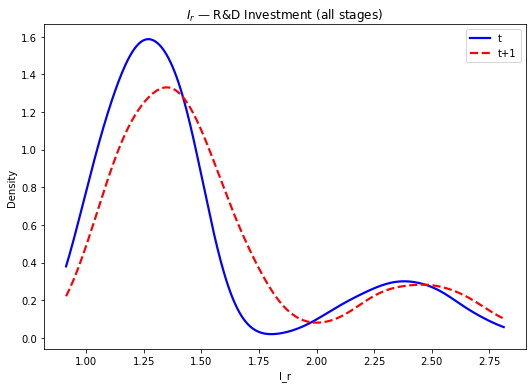

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_148.4/Ir_kde_all_by_lambda3.png


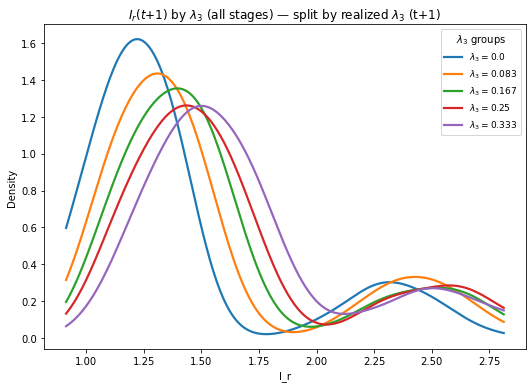

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_148.4/Id_kde_all.png


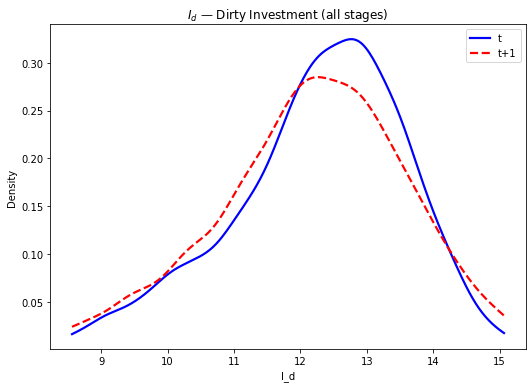

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_148.4/Id_kde_all_by_lambda3.png


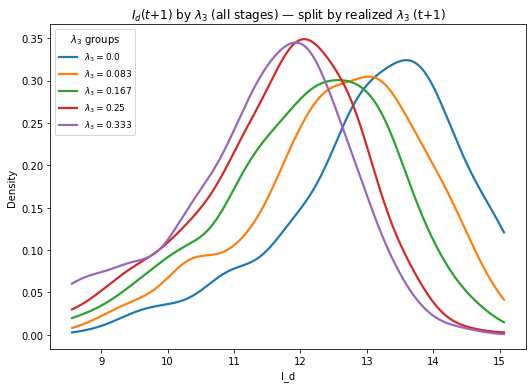

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_148.4/Ig_kde_all.png


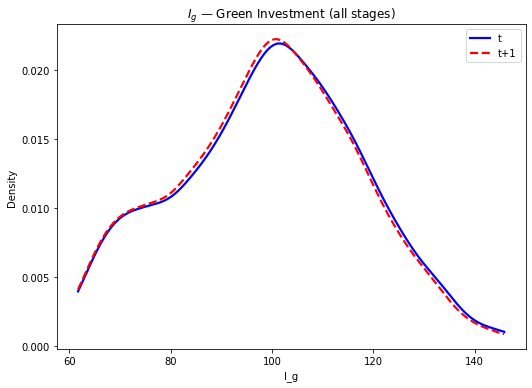

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_148.4/Ig_kde_all_by_lambda3.png


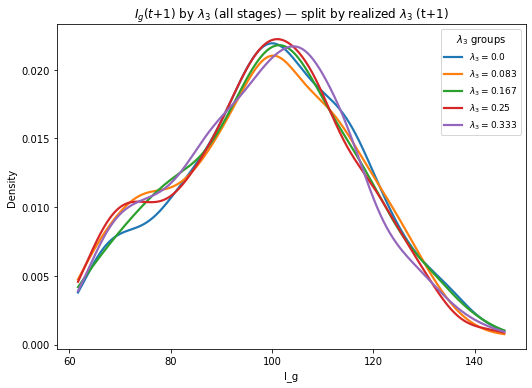

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_148.4/Ir_kde_stage0.png


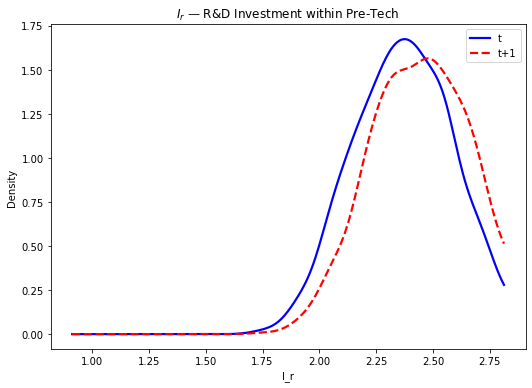

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_148.4/Ir_kde_stage0_by_lambda3.png


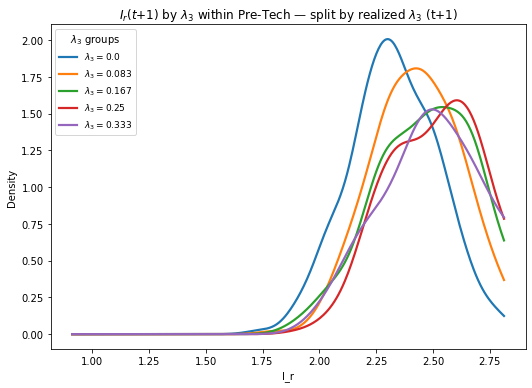

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_148.4/Id_kde_stage0.png


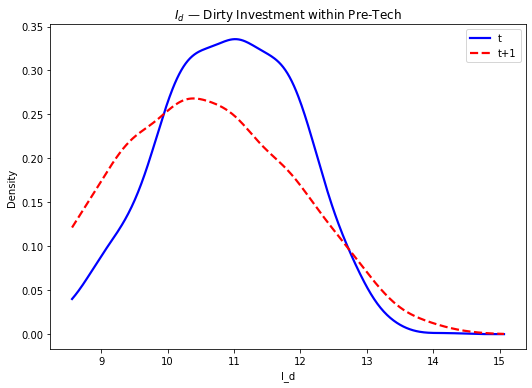

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_148.4/Id_kde_stage0_by_lambda3.png


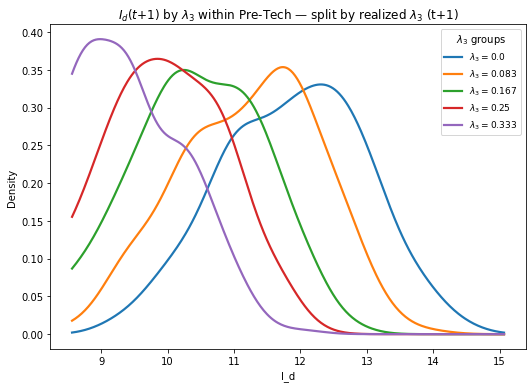

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_148.4/Ig_kde_stage0.png


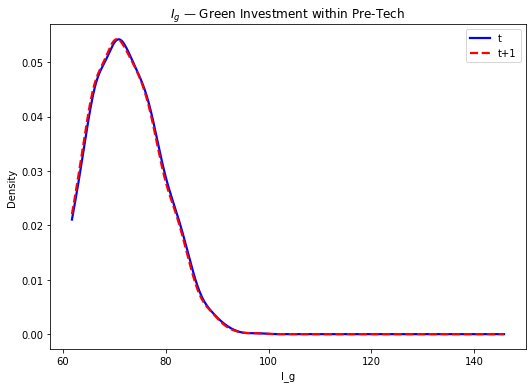

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_148.4/Ig_kde_stage0_by_lambda3.png


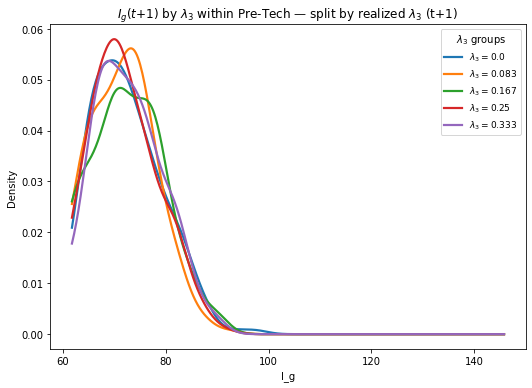

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_148.4/Ir_kde_stage1.png


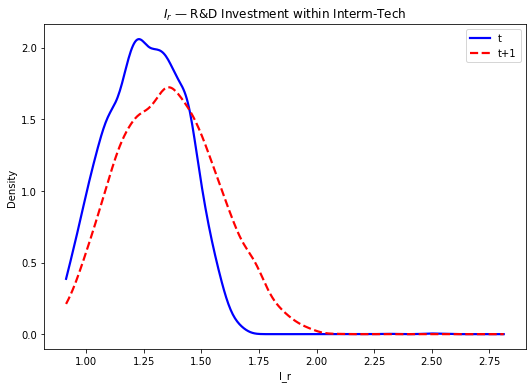

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_148.4/Ir_kde_stage1_by_lambda3.png


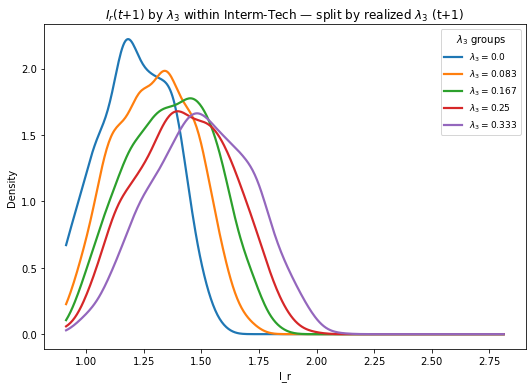

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_148.4/Id_kde_stage1.png


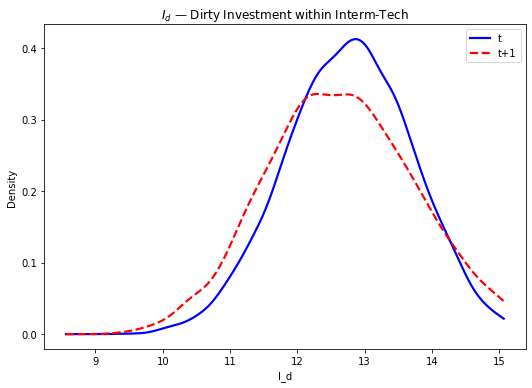

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_148.4/Id_kde_stage1_by_lambda3.png


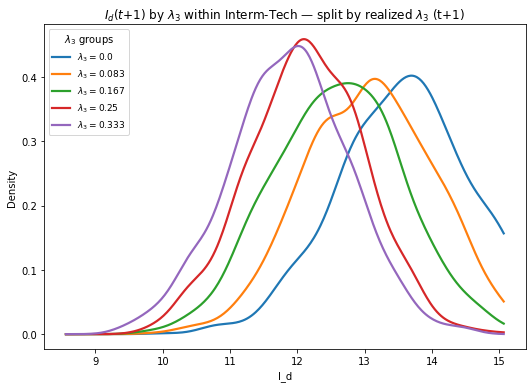

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_148.4/Ig_kde_stage1.png


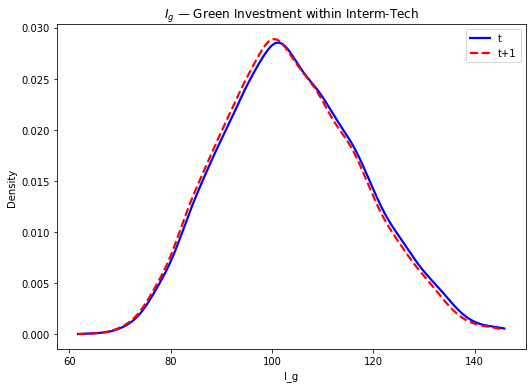

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_148.4/Ig_kde_stage1_by_lambda3.png


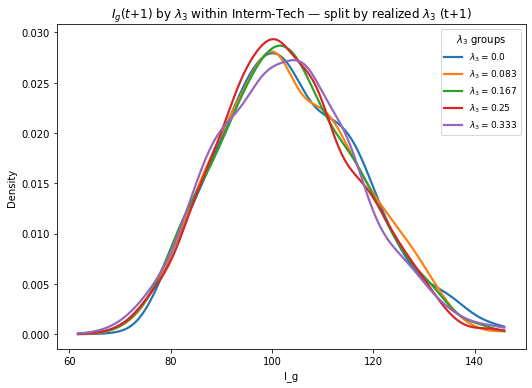

Skipping $I_r$ — R&D Investment within Post-Tech — insufficient data.
Skipping $I_r(t{+}1)$ by $\lambda_3$ within Post-Tech (by λ3) — no group meets MIN_PER_GROUP=10.
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_148.4/Id_kde_stage2.png


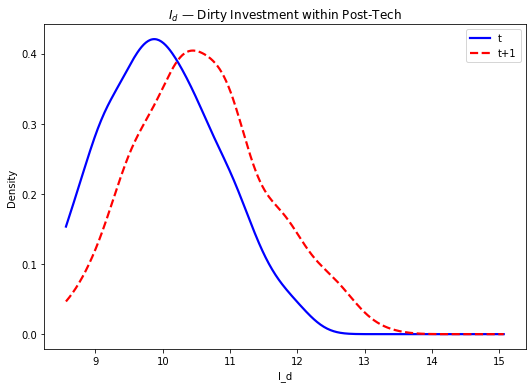

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_148.4/Id_kde_stage2_by_lambda3.png


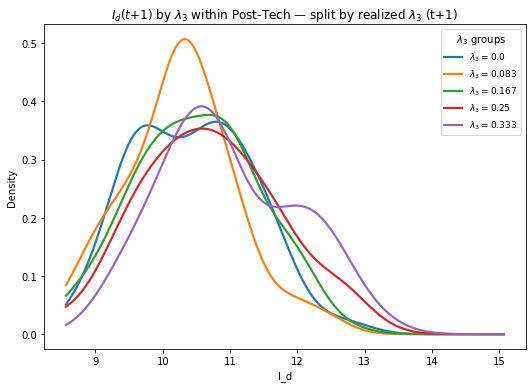

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_148.4/Ig_kde_stage2.png


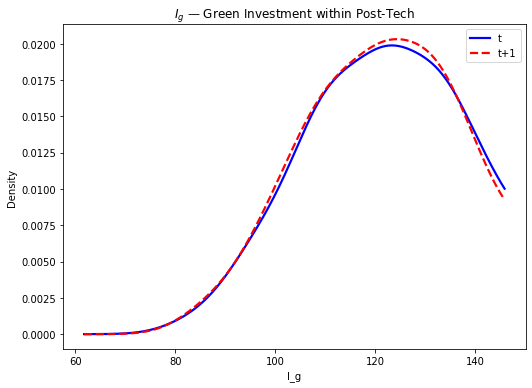

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_148.4/Ig_kde_stage2_by_lambda3.png


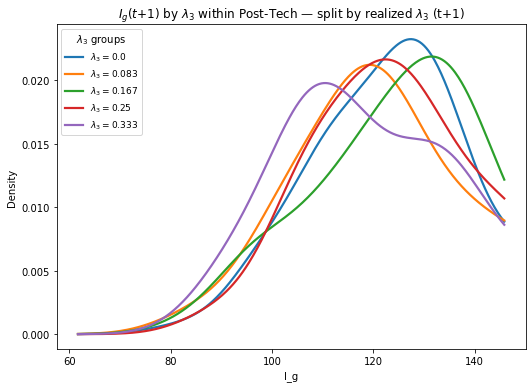

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# ---------- CONFIG ----------
base_folder = "/project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_148.4"
seed_min, seed_max = 1, 100
save_fig = True
STRICT_SAME_STAGE = True   # require tech stage(t) == stage(t+1) for stage-specific plots
LAMBDA3_ROUND = 3          # round λ3 values to group close floats
MIN_PER_GROUP = 10         # skip λ3 groups with too-few samples
# ----------------------------

Ir_t, Ir_t1 = [], []
Id_t, Id_t1 = [], []
Ig_t, Ig_t1 = [], []

# t+1 grouped by realized λ3 at the jump
Ir_t1_by_lam = defaultdict(list)
Id_t1_by_lam = defaultdict(list)
Ig_t1_by_lam = defaultdict(list)

stages = {0: "Pre-Tech", 1: "Interm-Tech", 2: "Post-Tech"}
Ir_stage = {s: {"t": [], "t1": []} for s in stages}
Id_stage = {s: {"t": [], "t1": []} for s in stages}
Ig_stage = {s: {"t": [], "t1": []} for s in stages}

# per-stage: t+1 grouped by λ3
Ir_t1_by_lam_stage = {s: defaultdict(list) for s in stages}
Id_t1_by_lam_stage = {s: defaultdict(list) for s in stages}
Ig_t1_by_lam_stage = {s: defaultdict(list) for s in stages}

def load_arrays(folder, seed):
    D   = np.load(os.path.join(folder, f"damage_state_array_{seed}.npy"))
    T   = np.load(os.path.join(folder, f"tech_state_array_{seed}.npy"))
    Ir  = np.load(os.path.join(folder, f"I_r_array_{seed}.npy"))
    Id  = np.load(os.path.join(folder, f"I_d_array_{seed}.npy"))
    Ig  = np.load(os.path.join(folder, f"I_g_array_{seed}.npy"))
    G3  = np.load(os.path.join(folder, f"gamma3_array_{seed}.npy"))  # realized λ3 path
    return D, T, Ir, Id, Ig, G3

for seed in range(seed_min, seed_max + 1):
    try:
        D, T, Ir, Id, Ig, G3 = load_arrays(base_folder, seed)
    except FileNotFoundError:
        print(f"[Seed {seed:03d}] missing files, skipping.")
        continue

    n_paths, T1 = D.shape
    for i in range(n_paths):
        d = D[i]
        # first transition 0 -> 1 (damage jump)
        trans = np.where((d[:-1] == 0) & (d[1:] == 1))[0]
        if trans.size == 0:
            continue
        t = trans[0] + 1  # index RIGHT AFTER the jump (compare t vs t+1)
        if t < 0 or t + 1 >= T1:
            continue

        ir_t,  ir_t1  = Ir[i, t],  Ir[i, t + 1]
        id_t,  id_t1  = Id[i, t],  Id[i, t + 1]
        ig_t,  ig_t1  = Ig[i, t],  Ig[i, t + 1]

        if np.isfinite(ir_t):  Ir_t.append(ir_t)
        if np.isfinite(ir_t1): Ir_t1.append(ir_t1)
        if np.isfinite(id_t):  Id_t.append(id_t)
        if np.isfinite(id_t1): Id_t1.append(id_t1)
        if np.isfinite(ig_t):  Ig_t.append(ig_t)
        if np.isfinite(ig_t1): Ig_t1.append(ig_t1)

        # realized λ3 at the jump time t (post-jump value)
        lam = G3[i, t]
        if np.isfinite(lam):
            lam_key = round(float(lam), LAMBDA3_ROUND) if LAMBDA3_ROUND is not None else float(lam)
            if np.isfinite(ir_t1): Ir_t1_by_lam[lam_key].append(ir_t1)
            if np.isfinite(id_t1): Id_t1_by_lam[lam_key].append(id_t1)
            if np.isfinite(ig_t1): Ig_t1_by_lam[lam_key].append(ig_t1)

        tb, ta = int(T[i, t]), int(T[i, t + 1])
        if tb in stages and ta in stages and ((not STRICT_SAME_STAGE) or (tb == ta)):
            s = tb
            if np.isfinite(ir_t):  Ir_stage[s]["t"].append(ir_t)
            if np.isfinite(ir_t1): Ir_stage[s]["t1"].append(ir_t1)
            if np.isfinite(id_t):  Id_stage[s]["t"].append(id_t)
            if np.isfinite(id_t1): Id_stage[s]["t1"].append(id_t1)
            if np.isfinite(ig_t):  Ig_stage[s]["t"].append(ig_t)
            if np.isfinite(ig_t1): Ig_stage[s]["t1"].append(ig_t1)

            # per-stage λ3 grouping for t+1
            if np.isfinite(lam) and np.isfinite(ir_t1):
                Ir_t1_by_lam_stage[s][lam_key].append(ir_t1)
            if np.isfinite(lam) and np.isfinite(id_t1):
                Id_t1_by_lam_stage[s][lam_key].append(id_t1)
            if np.isfinite(lam) and np.isfinite(ig_t1):
                Ig_t1_by_lam_stage[s][lam_key].append(ig_t1)

print(f"Collected {len(Ir_t)} I_r(t) and {len(Ir_t1)} I_r(t+1) samples.")
print(f"Collected {len(Id_t)} I_d(t) and {len(Id_t1)} I_d(t+1) samples.")
print(f"Collected {len(Ig_t)} I_g(t) and {len(Ig_t1)} I_g(t+1) samples.")

# ----------------------------
# Shared x-range (per variable)
# ----------------------------
def compute_range(arr):
    arr = np.asarray(arr, float)
    arr = arr[np.isfinite(arr)]
    if arr.size < 2:
        return None
    lo, hi = np.percentile(arr, [1, 99])
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        return None
    return (float(lo), float(hi))

Ir_all = np.array(Ir_t + Ir_t1, dtype=float)
Id_all = np.array(Id_t + Id_t1, dtype=float)
Ig_all = np.array(Ig_t + Ig_t1, dtype=float)

Ir_range = compute_range(Ir_all)
Id_range = compute_range(Id_all)
Ig_range = compute_range(Ig_all)

def plot_kde(data, label, color=None, linestyle="-", x_range=None):
    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]
    if data.size < 2:
        return False
    if np.allclose(np.std(data), 0):
        return False
    if x_range is None:
        lo, hi = np.percentile(data, [1, 99])
        if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
            return False
    else:
        lo, hi = x_range
    xs = np.linspace(lo, hi, 400)
    kde = gaussian_kde(data)
    if color is None:
        plt.plot(xs, kde(xs), lw=2.2, linestyle=linestyle, label=label)
    else:
        plt.plot(xs, kde(xs), color=color, lw=2.2, linestyle=linestyle, label=label)
    return True

def plot_density(x_t, x_t1, xlabel, title, filename, x_range=None):
    x_t  = [v for v in x_t  if np.isfinite(v)]
    x_t1 = [v for v in x_t1 if np.isfinite(v)]
    if len(x_t) == 0 or len(x_t1) == 0:
        print(f"Skipping {title} — insufficient data.")
        return

    plt.figure(figsize=(7.5, 5.5))
    ok1 = plot_kde(x_t,  "t",   "blue", "-", x_range=x_range)
    ok2 = plot_kde(x_t1, "t+1", "red",  "--", x_range=x_range)
    if not (ok1 and ok2):
        print(f"Skipping {title} — insufficient variance.")
        plt.close()
        return

    plt.xlabel(xlabel)
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    if save_fig:
        out = os.path.join(base_folder, filename)
        plt.savefig(out, dpi=150)
        print(f"Saved: {out}")
    plt.show()

def plot_density_by_lambda(groups_dict, xlabel, title, filename, x_range=None):
    """Plot t+1 density split by realized λ3 groups."""
    items = [(k, v) for k, v in groups_dict.items() if len(v) >= MIN_PER_GROUP]
    if len(items) == 0:
        print(f"Skipping {title} (by λ3) — no group meets MIN_PER_GROUP={MIN_PER_GROUP}.")
        return
    items.sort(key=lambda kv: kv[0])

    plt.figure(figsize=(7.5, 5.5))
    plotted = 0
    for lam, arr in items:
        ok = plot_kde(arr, label=fr"$\lambda_3={lam}$", x_range=x_range)
        if ok:
            plotted += 1
    if plotted < 1:
        print(f"Skipping {title} (by λ3) — insufficient variance.")
        plt.close()
        return

    plt.xlabel(xlabel)
    plt.ylabel("Density")
    plt.title(title + " — split by realized $\lambda_3$ (t+1)")
    plt.legend(title=r"$\lambda_3$ groups", fontsize=9)
    plt.tight_layout()
    if save_fig:
        out = os.path.join(base_folder, filename)
        plt.savefig(out, dpi=150)
        print(f"Saved: {out}")
    plt.show()

# ---- Pooled ----
plot_density(Ir_t, Ir_t1, "I_r", r"$I_r$ — R&D Investment (all stages)",
             "Ir_kde_all.png", x_range=Ir_range)
plot_density_by_lambda(Ir_t1_by_lam, "I_r",
             r"$I_r(t{+}1)$ by $\lambda_3$ (all stages)",
             "Ir_kde_all_by_lambda3.png", x_range=Ir_range)

plot_density(Id_t, Id_t1, "I_d", r"$I_d$ — Dirty Investment (all stages)",
             "Id_kde_all.png", x_range=Id_range)
plot_density_by_lambda(Id_t1_by_lam, "I_d",
             r"$I_d(t{+}1)$ by $\lambda_3$ (all stages)",
             "Id_kde_all_by_lambda3.png", x_range=Id_range)

plot_density(Ig_t, Ig_t1, "I_g", r"$I_g$ — Green Investment (all stages)",
             "Ig_kde_all.png", x_range=Ig_range)
plot_density_by_lambda(Ig_t1_by_lam, "I_g",
             r"$I_g(t{+}1)$ by $\lambda_3$ (all stages)",
             "Ig_kde_all_by_lambda3.png", x_range=Ig_range)

# ---- Per-tech-stage ----
for s, name in stages.items():
    plot_density(Ir_stage[s]["t"], Ir_stage[s]["t1"], "I_r",
                 rf"$I_r$ — R&D Investment within {name}", f"Ir_kde_stage{s}.png",
                 x_range=Ir_range)
    plot_density_by_lambda(Ir_t1_by_lam_stage[s], "I_r",
                           rf"$I_r(t{{+}}1)$ by $\lambda_3$ within {name}",
                           f"Ir_kde_stage{s}_by_lambda3.png", x_range=Ir_range)

    plot_density(Id_stage[s]["t"], Id_stage[s]["t1"], "I_d",
                 rf"$I_d$ — Dirty Investment within {name}", f"Id_kde_stage{s}.png",
                 x_range=Id_range)
    plot_density_by_lambda(Id_t1_by_lam_stage[s], "I_d",
                           rf"$I_d(t{{+}}1)$ by $\lambda_3$ within {name}",
                           f"Id_kde_stage{s}_by_lambda3.png", x_range=Id_range)

    plot_density(Ig_stage[s]["t"], Ig_stage[s]["t1"], "I_g",
                 rf"$I_g$ — Green Investment within {name}", f"Ig_kde_stage{s}.png",
                 x_range=Ig_range)
    plot_density_by_lambda(Ig_t1_by_lam_stage[s], "I_g",
                           rf"$I_g(t{{+}}1)$ by $\lambda_3$ within {name}",
                           f"Ig_kde_stage{s}_by_lambda3.png", x_range=Ig_range)
